# Random Forest Boruta

In [10]:
!pip install boruta


==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====
AUC: 0.852  |  Accuracy: 0.764  |  Sensitivity: 0.750
Specificity: 0.783  |  PPV: 0.828  |  NPV: 0.692  |  F1: 0.787

Features selected on full-data fit (9):
['Collagen 3 μg/mL Max Amp', 'Ristocetin 1.5 mg/mL AUC', 'PRP Endogenous Thrombin Potential', 'PRP Peak Thrombin Generation', 'PPP Endogenous Thrombin Potential', 'WB TF Lagtime', 'Luci GPVI Whole Blood', 'Luci Trap 6 PRP', 'PG Peak Plasmin']


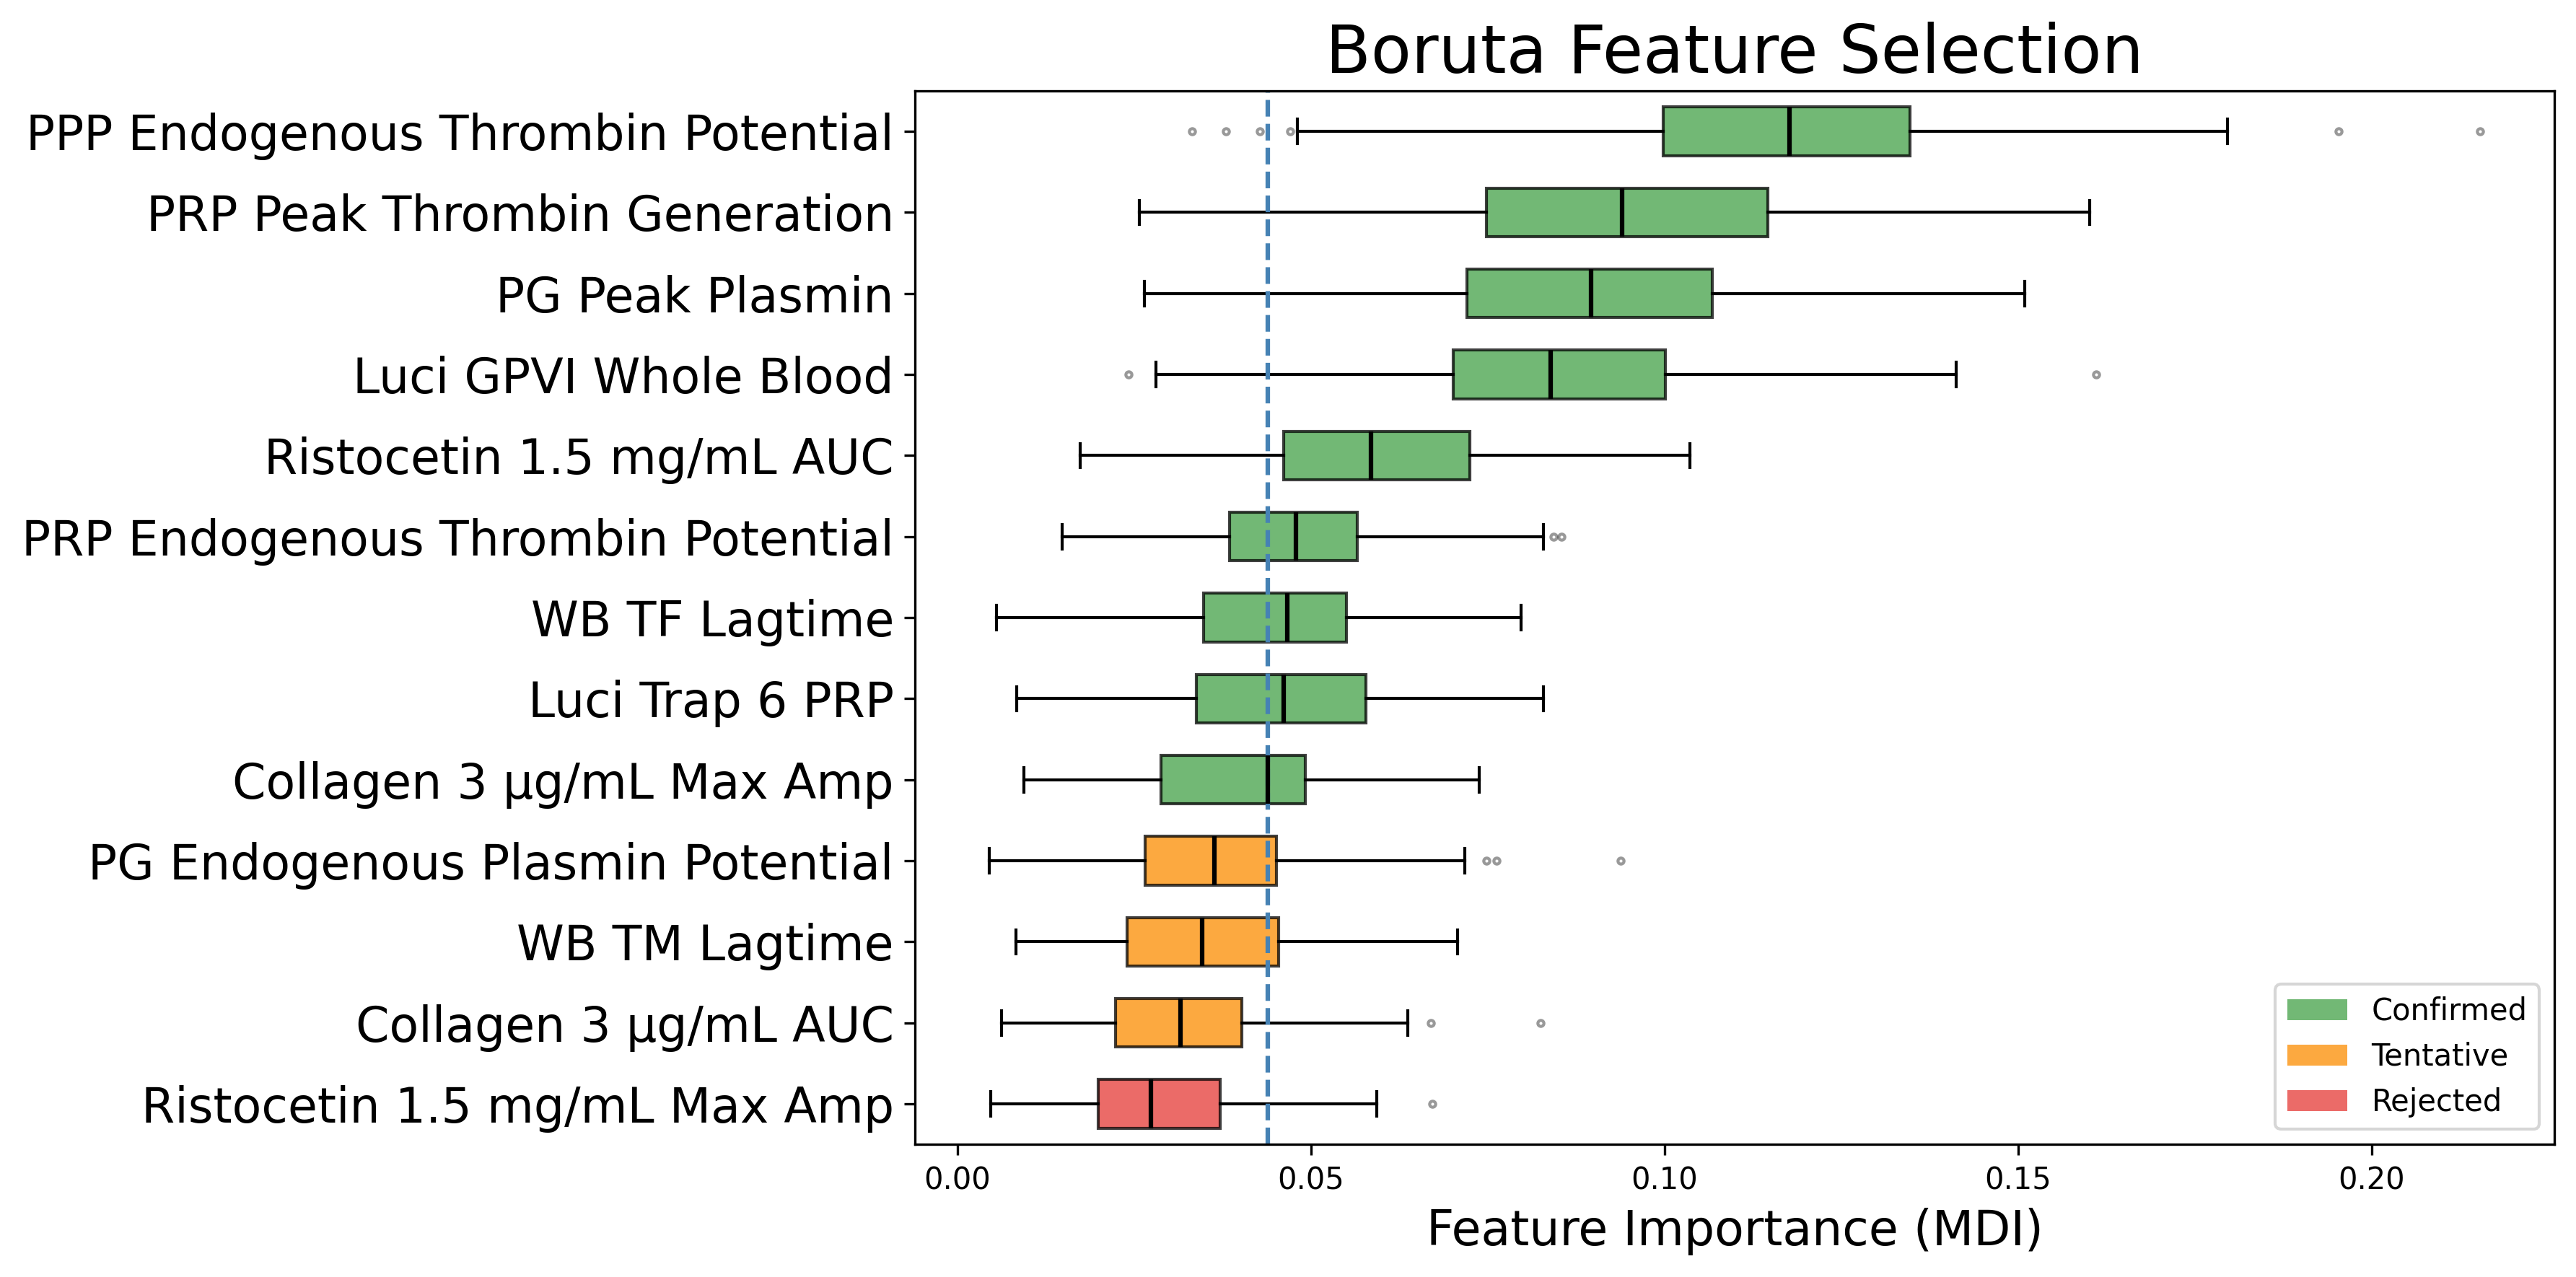

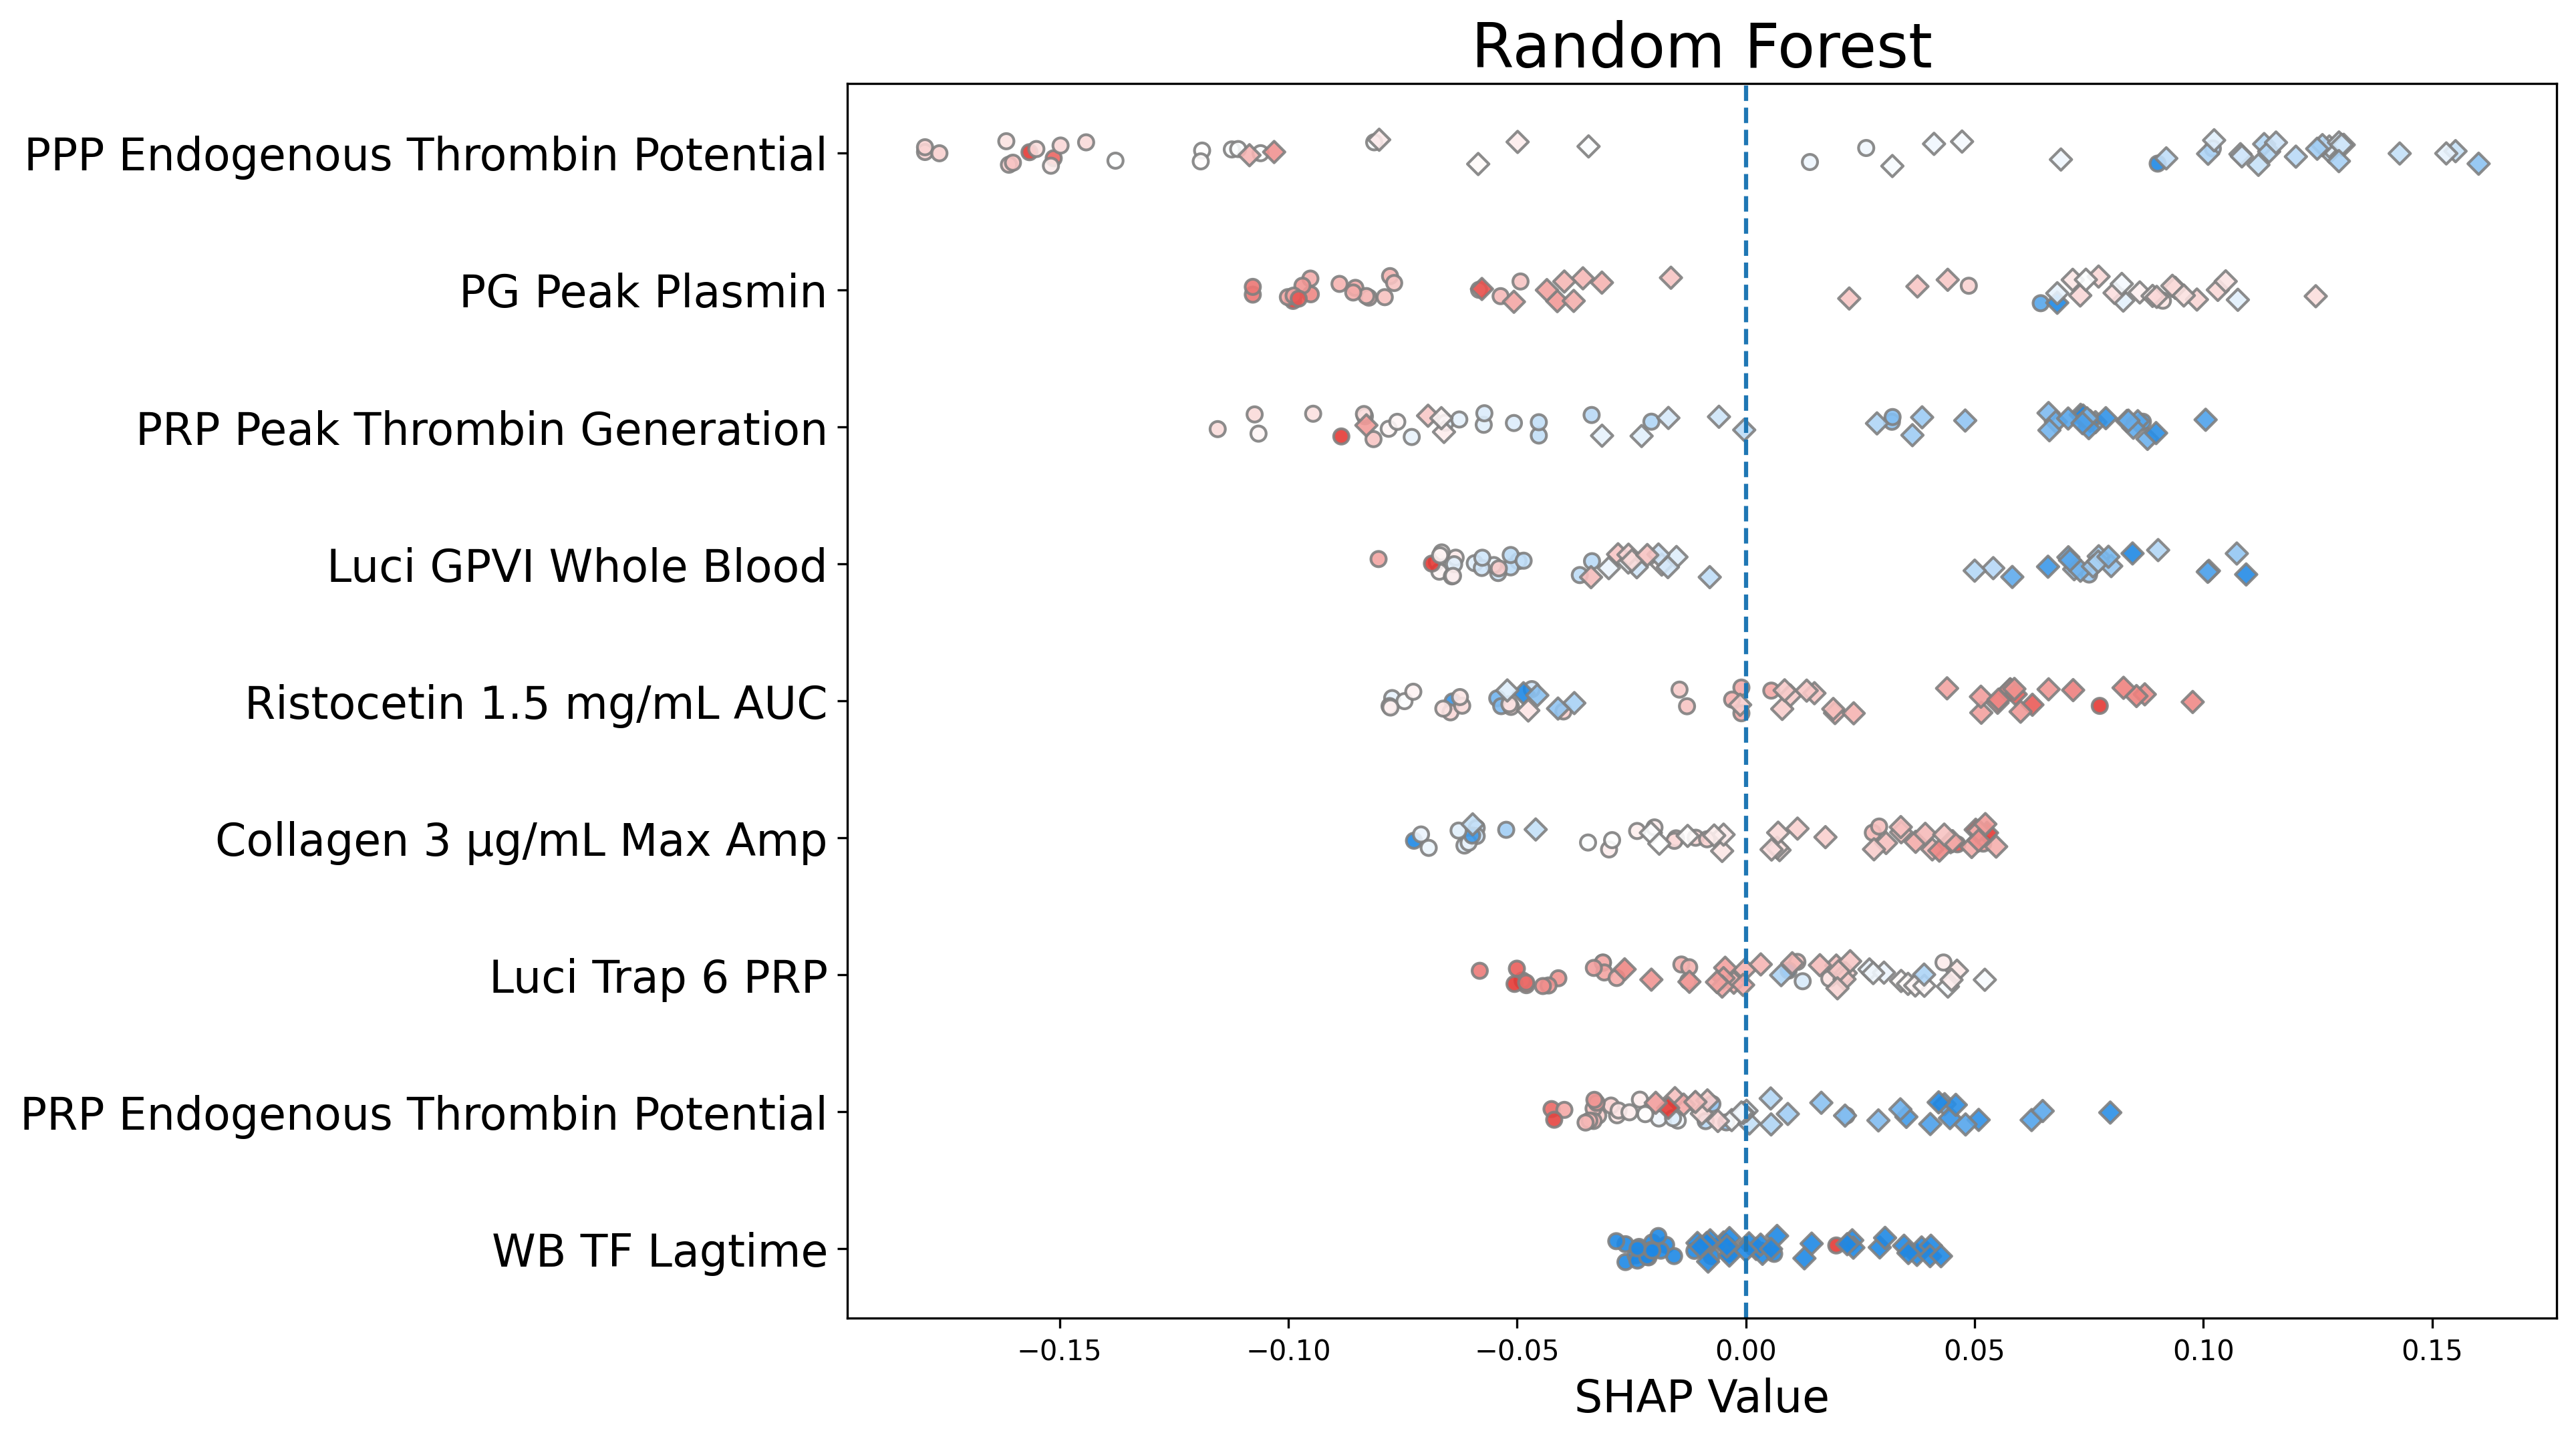


Saved ROC → roc_data/rf_boruta.pkl


In [11]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, os

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, accuracy_score, recall_score,
    precision_score, f1_score, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# Loading Patient data
# ─────────────────────────────────────────────
XGB_patients = pd.read_excel('BDUC_ML.xlsx') #32 patients
XGB_control  = pd.read_excel('BDUC_Controls.xlsx') #23 controls

BDUC_data = pd.concat([XGB_control, XGB_patients], axis=0, ignore_index=True)
BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'], # Drop personal data 
    errors="ignore"
)

X_full = BDUC_data.select_dtypes(include=[np.number]).copy()
cols_all = np.array(X_full.columns.tolist())
y = np.array([0]*23 + [1]*32) # 0 = control, 1 = patient

# ─────────────────────────────────────────────
# Boruta inside the pipeline (prevent data leakage)
# ─────────────────────────────────────────────
class BorutaSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=1000, max_iter=100, random_state=42):
        self.n_estimators        = n_estimators
        self.max_iter            = max_iter
        self.random_state        = random_state
        self.selected_idx_       = None
        self.support_            = None   
        self.support_weak_       = None   
        self.importance_history_ = None   

    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1,
            class_weight="balanced"
        )
        boruta = BorutaPy(
            estimator=rf,
            n_estimators='auto',
            max_iter=self.max_iter,
            random_state=self.random_state,
            verbose=0
        )
        boruta.fit(X, y)

        self.support_            = boruta.support_
        self.support_weak_       = boruta.support_weak_
        self.importance_history_ = boruta.importance_history_

        confirmed = np.where(boruta.support_)[0]
        tentative = np.where(boruta.support_weak_)[0]

        if len(confirmed) >= 3:
            self.selected_idx_ = confirmed
        else:
            self.selected_idx_ = np.concatenate([confirmed, tentative])

        return self

    def transform(self, X):
        return X[:, self.selected_idx_]

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)[self.selected_idx_]
        return self.selected_idx_

# ─────────────────────────────────────────────
# pipeline: impute → Boruta → RF
# ─────────────────────────────────────────────
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("boruta",  BorutaSelector(n_estimators=1000, max_iter=100, random_state=42)),
    ("rf",      RandomForestClassifier(
                    n_estimators=500,
                    max_depth=5,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1
                ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────────
# 5 fold cross validation
# ─────────────────────────────────────────────
y_pred_proba = cross_val_predict(
    pipe, X_full.values, y,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# ─────────────────────────────────────────────
# Youdens's J statistic for optimal probability threshold
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j       = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred         = (y_pred_proba >= best_threshold).astype(int)

# ─────────────────────────────────────────────
# Performance metrics
# ─────────────────────────────────────────────
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====")
print(f"AUC: {auc:.3f}  |  Accuracy: {accuracy:.3f}  |  Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}  |  PPV: {ppv:.3f}  |  NPV: {npv:.3f}  |  F1: {f1:.3f}")

# ─────────────────────────────────────────────
# Pipeline refit on all data to extract feature importance values
# ─────────────────────────────────────────────
pipe.fit(X_full.values, y)

selected_features = cols_all[pipe["boruta"].selected_idx_].tolist()
print(f"\nFeatures selected on full-data fit ({len(selected_features)}):")
print(selected_features)

importance_history = pipe["boruta"].importance_history_   
support            = pipe["boruta"].support_
support_weak       = pipe["boruta"].support_weak_

n_real   = len(cols_all)
real_imp = importance_history[:, :n_real]          

valid_rows = real_imp.any(axis=1)
real_imp   = real_imp[valid_rows]

medians       = np.median(real_imp, axis=0)
feature_order = np.argsort(medians)

def feature_colour(i):
    if support[i]:      return "#43A047"
    elif support_weak[i]: return "#FB8C00"
    else:               return "#E53935"

colours        = [feature_colour(i) for i in feature_order]
data_to_plot   = [real_imp[:, i]    for i in feature_order]
labels_to_plot = [cols_all[i]       for i in feature_order]

# Filter to features with median importance > 0
nonzero_mask  = medians > 0
feature_order = np.array([i for i in feature_order if nonzero_mask[i]])

colours        = [feature_colour(i) for i in feature_order]
data_to_plot   = [real_imp[:, i]    for i in feature_order]
labels_to_plot = [cols_all[i]       for i in feature_order]

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

bp = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    flierprops=dict(marker='o', markersize=2, alpha=0.4, linestyle='none')
)

for patch, colour in zip(bp["boxes"], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

# Estimate shadow threshold from the boruta object directly
boruta_obj = pipe["boruta"]

# Try to recover shadow history if stored
if hasattr(boruta_obj, '_shadow_max_history'):
    shadow_max = np.array(boruta_obj._shadow_max_history)[valid_rows]
    smin, smax = shadow_max.min(), shadow_max.max()
    ax.axvspan(smin, smax, alpha=0.12, color="steelblue", label="Shadow max range")
    ax.axvline(np.median(shadow_max), color="steelblue", linestyle="--",
               linewidth=1.5, label=f"Shadow max median ({np.median(shadow_max):.3f})")
else:
    # Fall back: draw a vertical line at the minimum confirmed feature median
    confirmed_medians = medians[support]
    if len(confirmed_medians):
        threshold_approx = confirmed_medians.min()
        ax.axvline(threshold_approx, color="steelblue", linestyle="--",
                   linewidth=1.5, label=f"Approx. threshold ({threshold_approx:.3f})")

ax.set_yticks(range(1, len(labels_to_plot) + 1))
ax.set_yticklabels(labels_to_plot, fontsize=16)
ax.set_xlabel("Feature Importance (MDI)", fontsize=16)
ax.set_title("Boruta Feature Selection", fontsize=22)

legend_patches = [
    mpatches.Patch(facecolor="#43A047", alpha=0.75, label="Confirmed"),
    mpatches.Patch(facecolor="#FB8C00", alpha=0.75, label="Tentative"),
    mpatches.Patch(facecolor="#E53935", alpha=0.75, label="Rejected"),
]
ax.legend(handles=legend_patches, fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig("boruta_importance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────
# SHAP
# ─────────────────────────────────────────────
X_transformed = pipe[:-1].transform(X_full.values)
X_shap = pd.DataFrame(X_transformed, columns=selected_features)

explainer   = shap.Explainer(pipe["rf"], X_shap)
shap_values = explainer(X_shap).values

sv_rf        = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
cols_to_keep = selected_features

# ─────────────────────────────────────────────
# SHAP Plot
# ─────────────────────────────────────────────
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_rf).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_rf[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    norm_vals = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    colors    = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos  = plot_idx + jitter

    ctrl_mask = y == 0
    case_mask = y == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask], c=colors[ctrl_mask],
               marker='o', s=30, alpha=0.9, edgecolors='grey')
    ax.scatter(shap_vals[case_mask], y_pos[case_mask], c=colors[case_mask],
               marker='D', s=30, alpha=0.9, edgecolors='grey')

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_title("Random Forest", fontsize=22)
ax.set_xlabel("SHAP Value", fontsize=16)

plt.show()

# ─────────────────────────────────────────────
# SAVE ROC data
# ─────────────────────────────────────────────
PREFIX = "rf_boruta"
os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump({"fpr": fpr, "tpr": tpr, "auc": auc, "label": PREFIX}, f)
print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# Random Forest Thrombin


==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====
AUC: 0.865  |  Accuracy: 0.818  |  Sensitivity: 0.812
Specificity: 0.826  |  PPV: 0.867  |  NPV: 0.760  |  F1: 0.839

Features selected on full-data fit (4):
['PRP Endogenous Thrombin Potential', 'PRP Peak Thrombin Generation', 'PPP Endogenous Thrombin Potential', 'WB TF Endogenous Thrombin Potential']


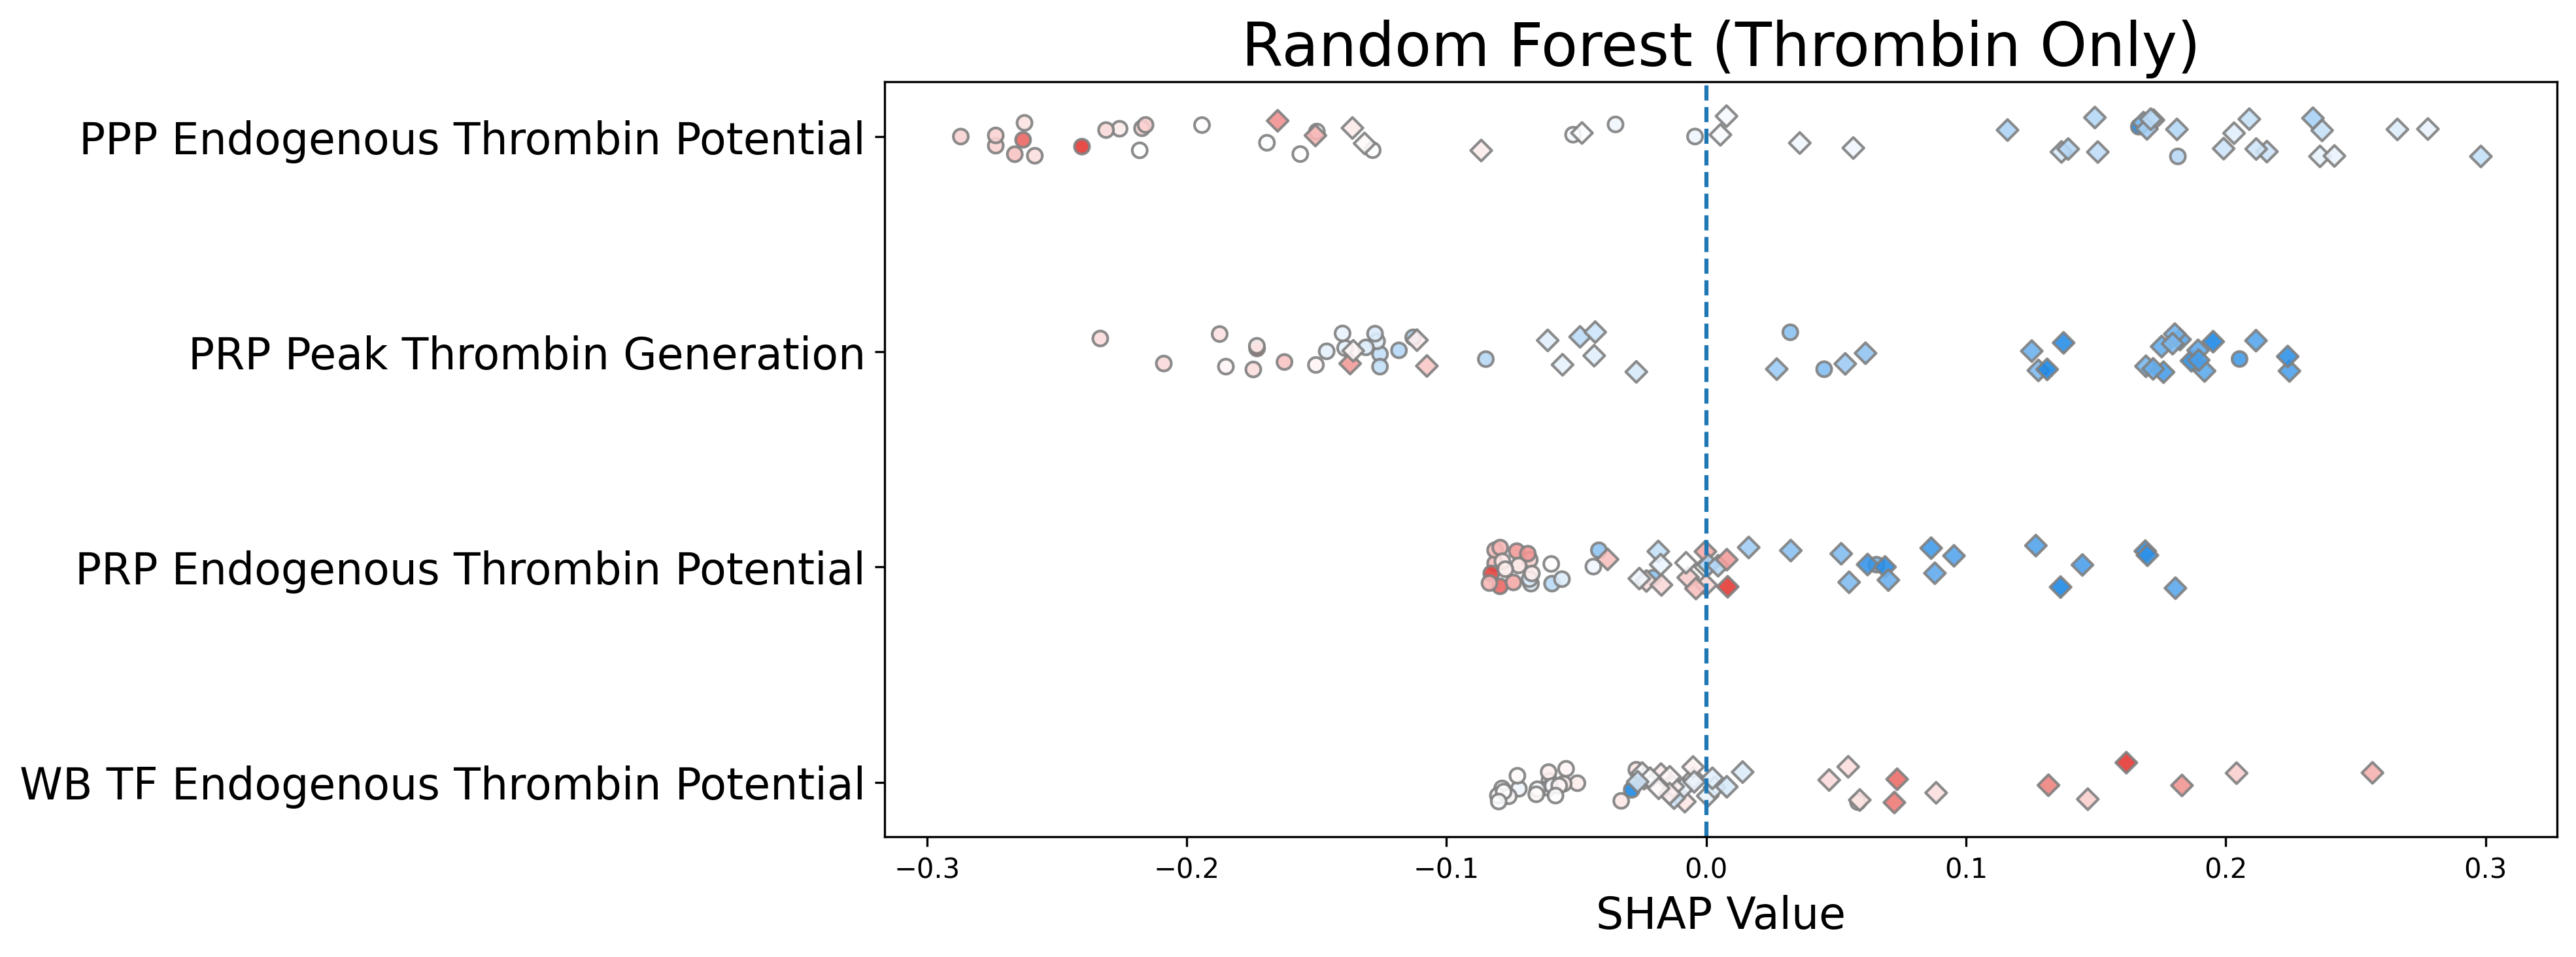


Saved ROC → roc_data/rf_thrombin.pkl


In [12]:
# ─────────────────────────────────────────────
# Loading Patient data
# ─────────────────────────────────────────────
XGB_patients = pd.read_excel('BDUC_ML.xlsx') #32 patients
XGB_control  = pd.read_excel('BDUC_Controls.xlsx') #23 controls

BDUC_data = pd.concat([XGB_control, XGB_patients], axis=0, ignore_index=True)
BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'], # Drop personal data 
    errors="ignore"
)

cols_to_keep = [
    'PRP Endogenous Thrombin Potential',
    'PRP Peak Thrombin Generation',
    'PPP Endogenous Thrombin Potential',
    'PPP Peak Thrombin Generation',
    'WB TF Endogenous Thrombin Potential',
    'WB TM Endogenous Thrombin Potential'
    
]

BDUC_data = BDUC_data.loc[:, cols_to_keep]

X_full = BDUC_data.select_dtypes(include=[np.number]).copy()
cols_all = np.array(X_full.columns.tolist())
y = np.array([0]*23 + [1]*32) # 0 = control, 1 = patient

# ─────────────────────────────────────────────
# Boruta inside the pipeline (prevent data leakage)
# ─────────────────────────────────────────────
class BorutaSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=1000, max_iter=100, random_state=42):
        self.n_estimators        = n_estimators
        self.max_iter            = max_iter
        self.random_state        = random_state
        self.selected_idx_       = None
        self.support_            = None   
        self.support_weak_       = None   
        self.importance_history_ = None   

    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1,
            class_weight="balanced"
        )
        boruta = BorutaPy(
            estimator=rf,
            n_estimators='auto',
            max_iter=self.max_iter,
            random_state=self.random_state,
            verbose=0
        )
        boruta.fit(X, y)

        self.support_            = boruta.support_
        self.support_weak_       = boruta.support_weak_
        self.importance_history_ = boruta.importance_history_

        confirmed = np.where(boruta.support_)[0]
        tentative = np.where(boruta.support_weak_)[0]

        if len(confirmed) >= 3:
            self.selected_idx_ = confirmed
        else:
            self.selected_idx_ = np.concatenate([confirmed, tentative])

        return self

    def transform(self, X):
        return X[:, self.selected_idx_]

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)[self.selected_idx_]
        return self.selected_idx_

# ─────────────────────────────────────────────
# PIPELINE: impute → Boruta → RF
# ─────────────────────────────────────────────
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("boruta",  BorutaSelector(n_estimators=1000, max_iter=100, random_state=42)),
    ("rf",      RandomForestClassifier(
                    n_estimators=500,
                    max_depth=5,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1
                ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────────
# 5 fold cross validation
# ─────────────────────────────────────────────
y_pred_proba = cross_val_predict(
    pipe, X_full.values, y,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# ─────────────────────────────────────────────
# Youdens's J statistic for optimal probability threshold
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j       = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred         = (y_pred_proba >= best_threshold).astype(int)

# ─────────────────────────────────────────────
# Performance metrics
# ─────────────────────────────────────────────
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====")
print(f"AUC: {auc:.3f}  |  Accuracy: {accuracy:.3f}  |  Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}  |  PPV: {ppv:.3f}  |  NPV: {npv:.3f}  |  F1: {f1:.3f}")

# ─────────────────────────────────────────────
# Boruta feature selection
# ─────────────────────────────────────────────
pipe.fit(X_full.values, y)

selected_features = cols_all[pipe["boruta"].selected_idx_].tolist()
print(f"\nFeatures selected on full-data fit ({len(selected_features)}):")
print(selected_features)

# ─────────────────────────────────────────────
# SHAP
# ─────────────────────────────────────────────
X_transformed = pipe[:-1].transform(X_full.values)
X_shap = pd.DataFrame(X_transformed, columns=selected_features)

explainer   = shap.Explainer(pipe["rf"], X_shap)
shap_values = explainer(X_shap).values

sv_rf        = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
cols_to_keep = selected_features

# ─────────────────────────────────────────────
# SHAP PLOT
# ─────────────────────────────────────────────
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_rf).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_rf[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    norm_vals = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    colors    = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos  = plot_idx + jitter

    ctrl_mask = y == 0
    case_mask = y == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask], c=colors[ctrl_mask],
               marker='o', s=30, alpha=0.9, edgecolors='grey')
    ax.scatter(shap_vals[case_mask], y_pos[case_mask], c=colors[case_mask],
               marker='D', s=30, alpha=0.9, edgecolors='grey')

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_title("Random Forest (Thrombin Only)", fontsize=22)
ax.set_xlabel("SHAP Value", fontsize=16)

plt.show()

# ─────────────────────────────────────────────
# ROC data
# ─────────────────────────────────────────────
PREFIX = "rf_thrombin"
os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump({"fpr": fpr, "tpr": tpr, "auc": auc, "label": PREFIX}, f)
print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# Random Forest ATP Release


==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====
AUC: 0.760  |  Accuracy: 0.691  |  Sensitivity: 0.531
Specificity: 0.913  |  PPV: 0.895  |  NPV: 0.583  |  F1: 0.667

Features selected on full-data fit (3):
['Luci GPVI Whole Blood', 'Luci Trap 6 PRP', 'Luci Trap 6 Whole Blood']


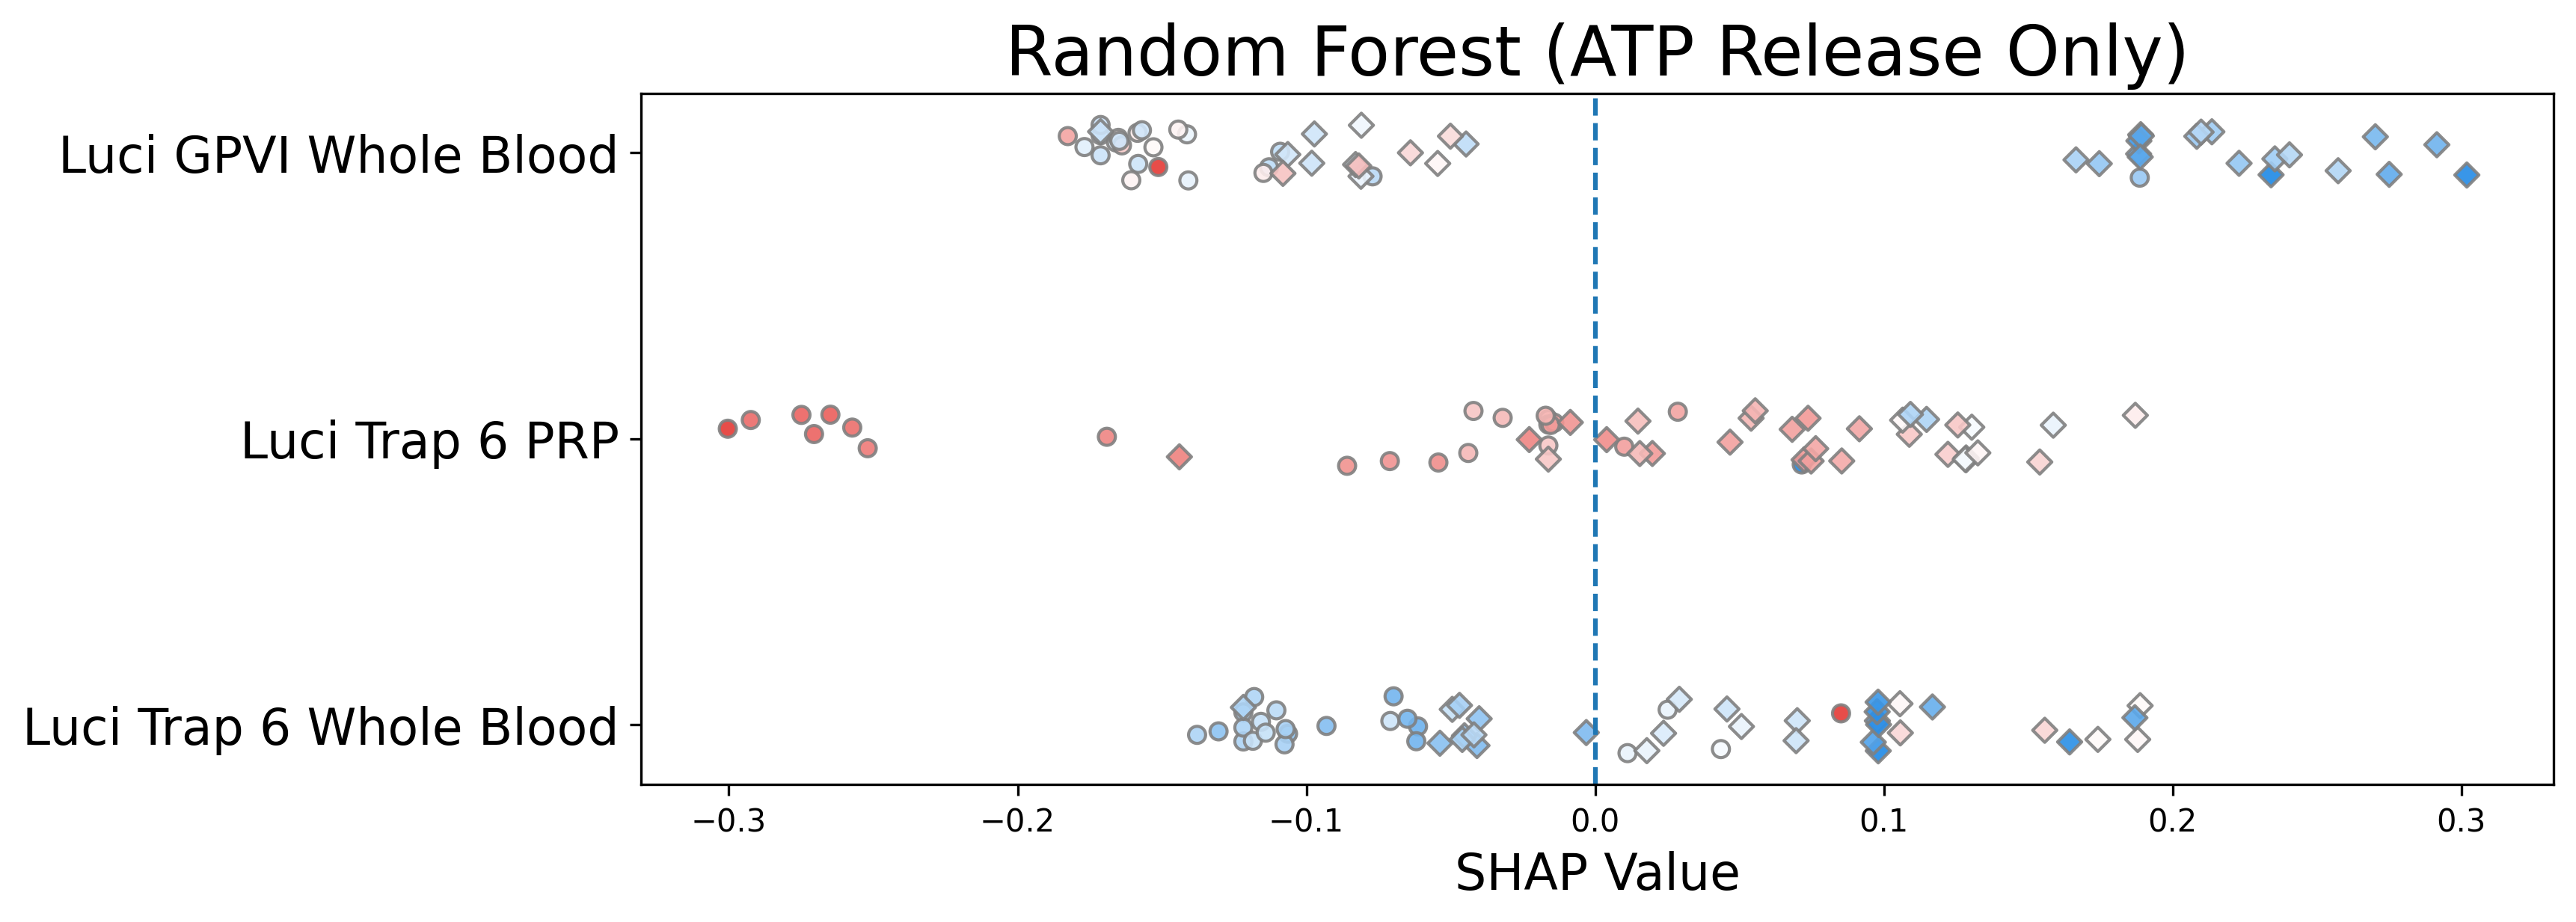


Saved ROC → roc_data/rf_atp.pkl


In [13]:

# ─────────────────────────────────────────────
# DATA LOADING
# ─────────────────────────────────────────────
XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control  = pd.read_excel('BDUC_Controls.xlsx')

BDUC_data = pd.concat([XGB_control, XGB_patients], axis=0, ignore_index=True)
BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

cols_to_keep = [
    'Luci Trap 6 Whole Blood',
    'Luci GPVI Whole Blood',
    'Luci Trap 6 PRP',
    'Luci GPVI PRP'
]

BDUC_data = BDUC_data.loc[:, cols_to_keep]

X_full = BDUC_data.select_dtypes(include=[np.number]).copy()
cols_all = np.array(X_full.columns.tolist())
y = np.array([0]*23 + [1]*32)

# ─────────────────────────────────────────────
# CUSTOM TRANSFORMER: Boruta inside the pipeline
# ─────────────────────────────────────────────
class BorutaSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=1000, max_iter=100, random_state=42):
        self.n_estimators        = n_estimators
        self.max_iter            = max_iter
        self.random_state        = random_state
        self.selected_idx_       = None
        self.support_            = None   # ← added
        self.support_weak_       = None   # ← added
        self.importance_history_ = None   # ← added

    def fit(self, X, y):
        rf = RandomForestClassifier(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1,
            class_weight="balanced"
        )
        boruta = BorutaPy(
            estimator=rf,
            n_estimators='auto',
            max_iter=self.max_iter,
            random_state=self.random_state,
            verbose=0
        )
        boruta.fit(X, y)

        # ← expose internals needed for the importance plot
        self.support_            = boruta.support_
        self.support_weak_       = boruta.support_weak_
        self.importance_history_ = boruta.importance_history_

        confirmed = np.where(boruta.support_)[0]
        tentative = np.where(boruta.support_weak_)[0]

        if len(confirmed) >= 3:
            self.selected_idx_ = confirmed
        else:
            self.selected_idx_ = np.concatenate([confirmed, tentative])

        return self

    def transform(self, X):
        return X[:, self.selected_idx_]

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)[self.selected_idx_]
        return self.selected_idx_

# ─────────────────────────────────────────────
# PIPELINE: impute → Boruta → RF
# ─────────────────────────────────────────────
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("boruta",  BorutaSelector(n_estimators=1000, max_iter=100, random_state=42)),
    ("rf",      RandomForestClassifier(
                    n_estimators=500,
                    max_depth=5,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1
                ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────────────────────────────────────
# CV PREDICTIONS (no leakage)
# ─────────────────────────────────────────────
y_pred_proba = cross_val_predict(
    pipe, X_full.values, y,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# ─────────────────────────────────────────────
# YOUDEN'S J THRESHOLD
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j       = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred         = (y_pred_proba >= best_threshold).astype(int)

# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE (BORUTA — LEAKAGE-FREE CV) ====")
print(f"AUC: {auc:.3f}  |  Accuracy: {accuracy:.3f}  |  Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}  |  PPV: {ppv:.3f}  |  NPV: {npv:.3f}  |  F1: {f1:.3f}")

# ─────────────────────────────────────────────
# FINAL FIT ON FULL DATA (for SHAP + Boruta plot)
# ─────────────────────────────────────────────
pipe.fit(X_full.values, y)

selected_features = cols_all[pipe["boruta"].selected_idx_].tolist()
print(f"\nFeatures selected on full-data fit ({len(selected_features)}):")
print(selected_features)

# ─────────────────────────────────────────────
# SHAP
# ─────────────────────────────────────────────
X_transformed = pipe[:-1].transform(X_full.values)
X_shap = pd.DataFrame(X_transformed, columns=selected_features)

explainer   = shap.Explainer(pipe["rf"], X_shap)
shap_values = explainer(X_shap).values

sv_rf        = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
cols_to_keep = selected_features

# ─────────────────────────────────────────────
# SHAP PLOT
# ─────────────────────────────────────────────
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_rf).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1]
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 4), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_rf[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    norm_vals = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-8)
    colors    = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos  = plot_idx + jitter

    ctrl_mask = y == 0
    case_mask = y == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask], c=colors[ctrl_mask],
               marker='o', s=30, alpha=0.9, edgecolors='grey')
    ax.scatter(shap_vals[case_mask], y_pos[case_mask], c=colors[case_mask],
               marker='D', s=30, alpha=0.9, edgecolors='grey')

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_title("Random Forest (ATP Release Only)", fontsize=22)
ax.set_xlabel("SHAP Value", fontsize=16)

plt.show()

# ─────────────────────────────────────────────
# SAVE ROC
# ─────────────────────────────────────────────
PREFIX = "rf_atp"
os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump({"fpr": fpr, "tpr": tpr, "auc": auc, "label": PREFIX}, f)
print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# LightGBM 

Best LightGBM parameters: {'clf__colsample_bytree': 0.5, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__min_child_samples': 20, 'clf__n_estimators': 50, 'clf__num_leaves': 4, 'clf__reg_alpha': 0.1, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Best LightGBM ROC AUC: 0.8885714285714286

Best threshold (Youden's J): 0.562

==== PERFORMANCE METRICS ====
AUC: 0.882
Accuracy: 0.836
Sensitivity: 0.875
Specificity: 0.783
PPV: 0.848
NPV: 0.818
F1: 0.862
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

Selected 8 stable features:
['Collagen 3 μg/mL Max Amp', 'Ristocetin 1.5 mg/mL AUC', 'PRP Peak Thrombin Generation', 'PPP Endogenous Thrombin Potential', 'WB TF Lagtime', 'Luci GPVI Whole Blood', 'Luci Trap 6 PRP', 'PG Peak Plasmin']


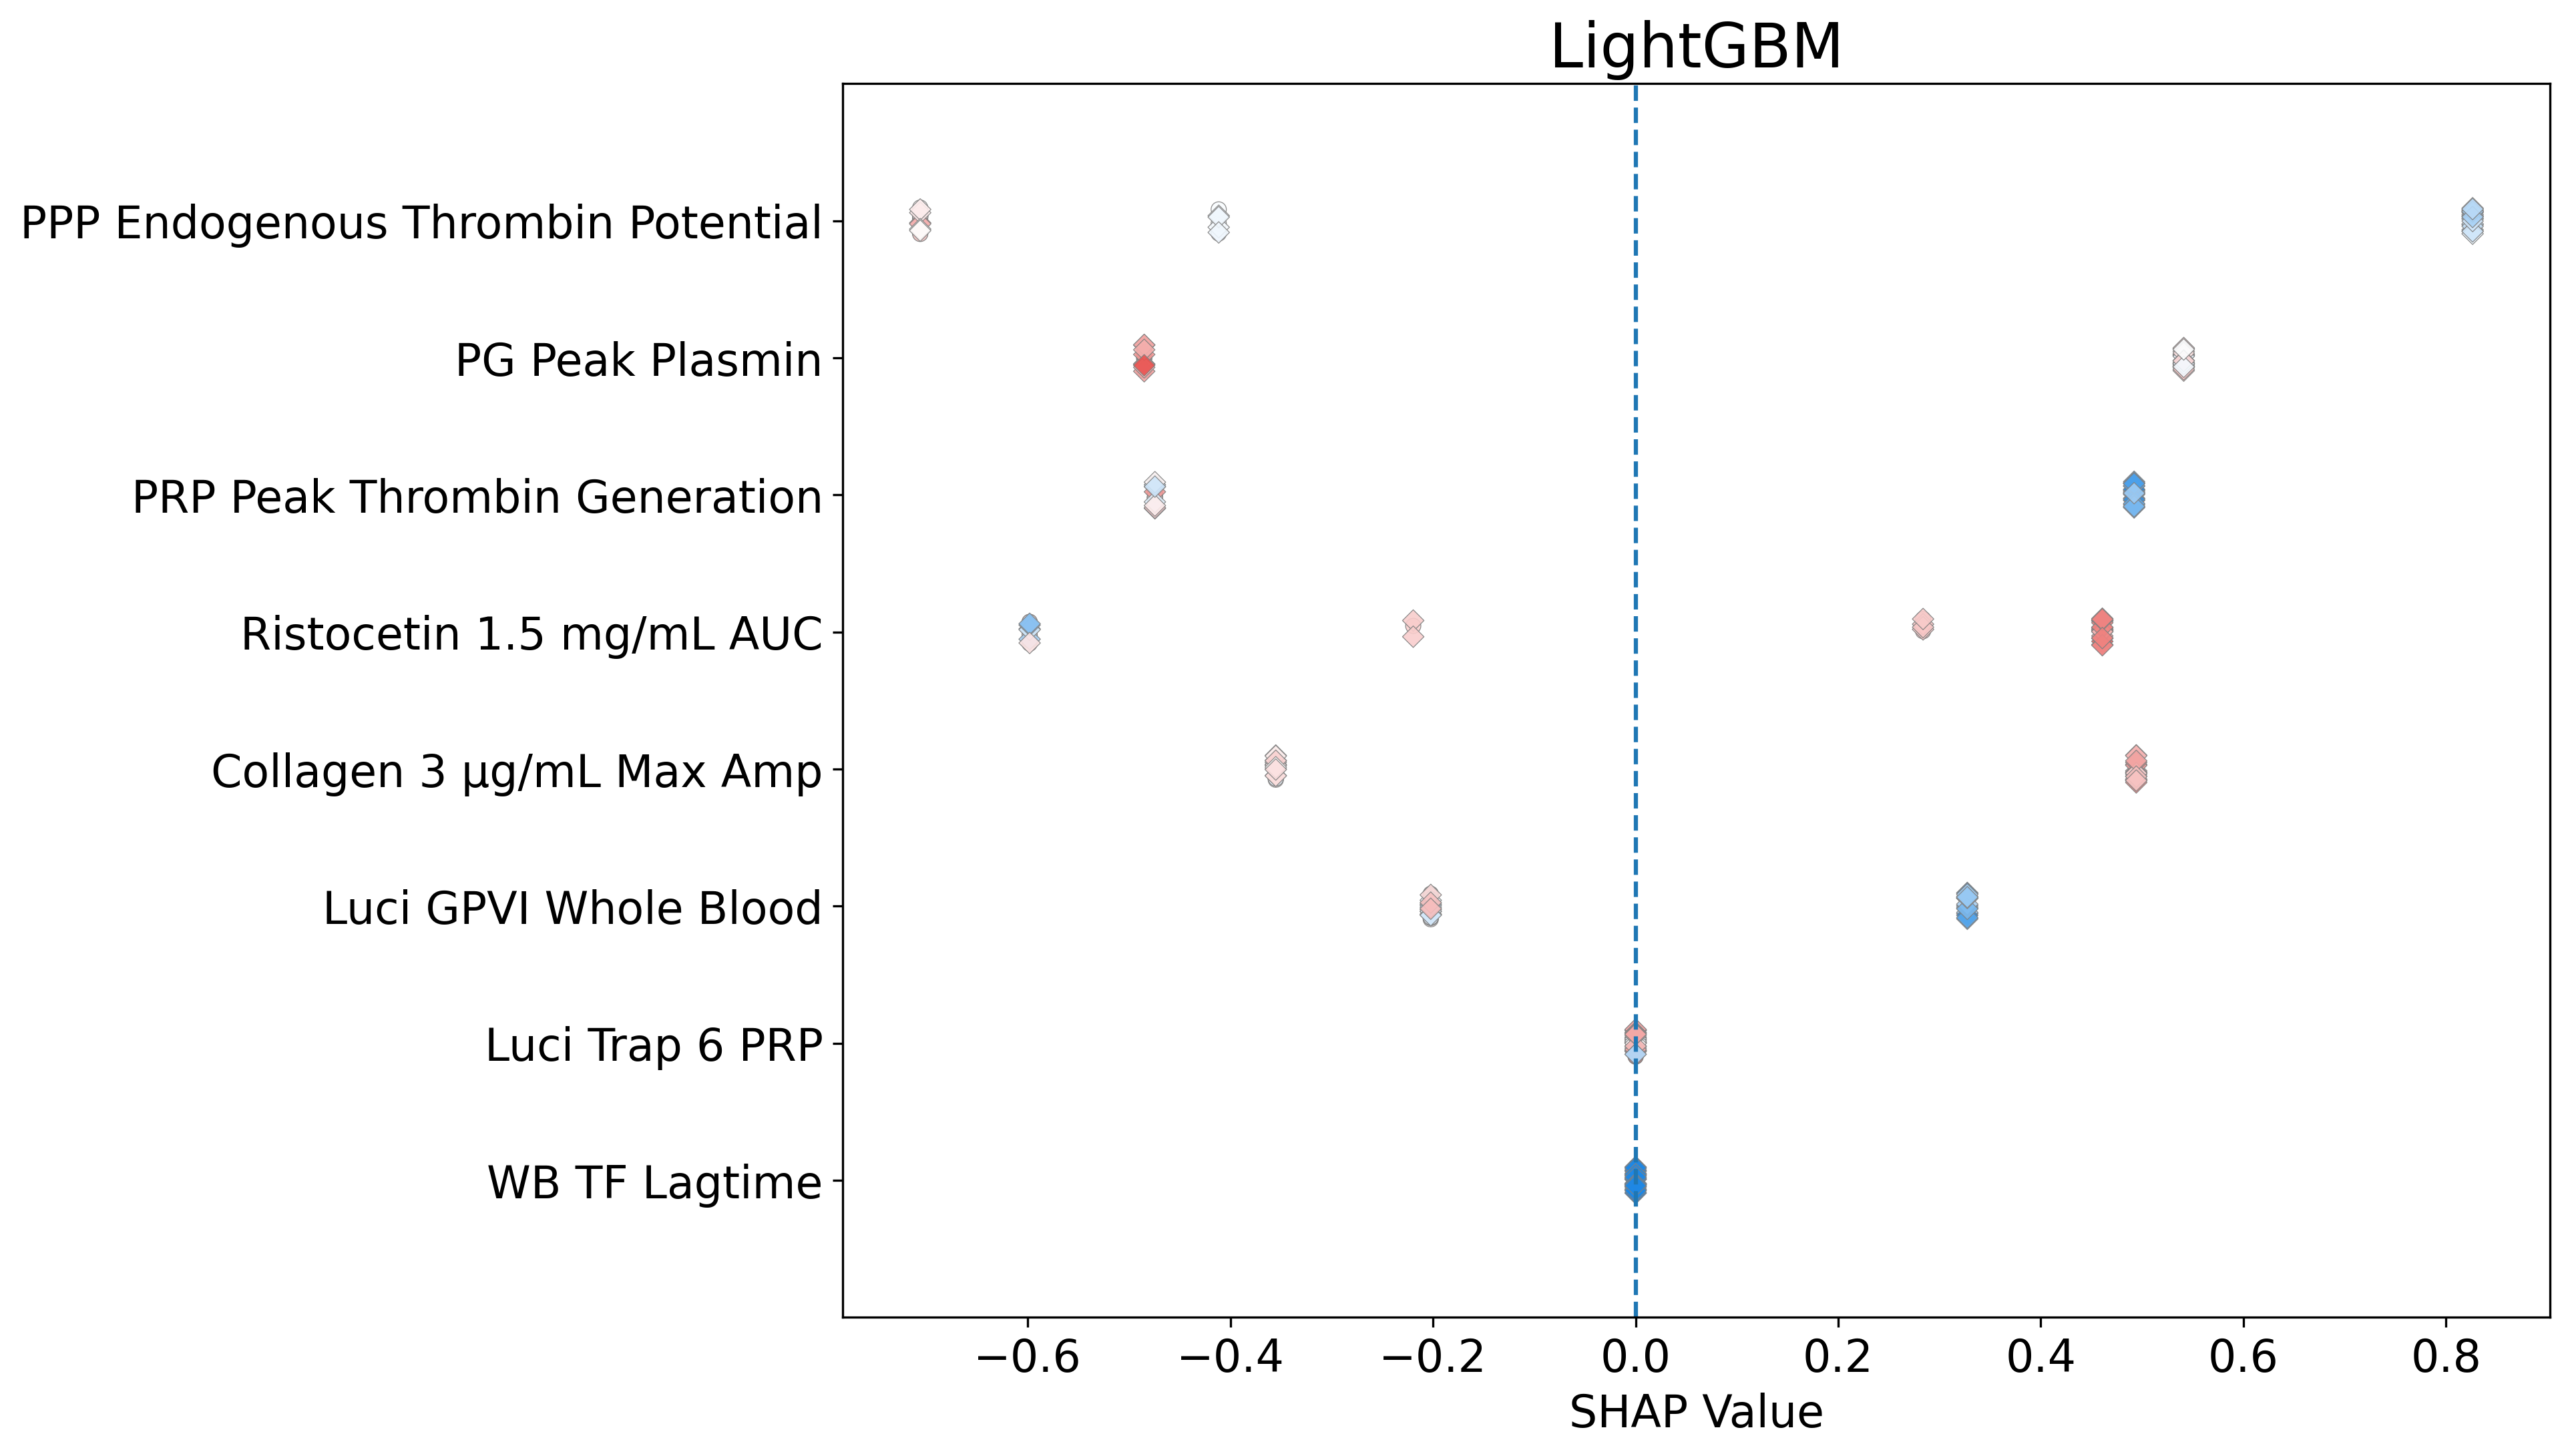


Saved ROC → roc_data/lgbm.pkl


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from lightgbm import LGBMClassifier
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

# -----------------------------
# Data loading
# -----------------------------
XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

XGB_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

XGB_data = XGB_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

XGB_data.columns = XGB_data.columns.str.strip()
XGB_data = XGB_data.select_dtypes(include=[np.number])  # fix: drop non-numeric

# -----------------------------
# Features + target
# -----------------------------
X = XGB_data.copy()
y = np.array([0]*23 + [1]*32)

# -----------------------------
# Pipeline: impute -> scale -> LGBM
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

param_grid = {
    "clf__max_depth": [2, 3],
    "clf__num_leaves": [4, 8, 16],
    "clf__min_child_samples": [10, 15, 20, 30],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.5, 0.7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__n_estimators": [50, 100, 200],
    "clf__reg_alpha": [0.1, 1.0],   # add L1
    "clf__reg_lambda": [1.0, 5.0],  # add L2
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_lgb = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

model_lgb.fit(X, y)

print("Best LightGBM parameters:", model_lgb.best_params_)
print("Best LightGBM ROC AUC:", model_lgb.best_score_)

# -----------------------------
# CV predictions (no leakage)
# -----------------------------
best_lgb = model_lgb.best_estimator_

y_pred_proba = cross_val_predict(
    best_lgb,
    X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# -----------------------------
# Youden's J
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_pred_proba >= best_threshold).astype(int)

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\nBest threshold (Youden's J):", round(best_threshold, 3))
print("\n==== PERFORMANCE METRICS ====")
print("AUC:", round(auc, 3))
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("PPV:", round(ppv, 3))
print("NPV:", round(npv, 3))
print("F1:", round(f1, 3))

# -----------------------------
# SHAP values
# -----------------------------
X_transformed = best_lgb[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

# Ensure reproducibility
RANDOM_STATE = 42
N_SPLITS = 5

X = X_shap.copy()
y_array = np.array(y)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

feature_names = X.columns
shap_importance_accum = np.zeros(len(feature_names))

# Store per-fold importance (for stability)
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_array)):
    print(f"Fold {fold+1}/{N_SPLITS}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Train model (same hyperparameters as best_lgb)
    model = LGBMClassifier(**best_lgb["clf"].get_params())
    model.fit(X_train, y_train)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_val)

    # Binary classification → take class 1
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_importance_accum += mean_abs_shap
    fold_importances.append(mean_abs_shap)

# Average importance across folds
shap_importance_mean = shap_importance_accum / N_SPLITS
fold_importances = np.array(fold_importances)

# Rank features per fold
rankings = np.argsort(-fold_importances, axis=1)

# Convert ranks to top-k inclusion (e.g. top 20 per fold)
TOP_K = 20

selection_matrix = np.zeros_like(fold_importances)

for i in range(N_SPLITS):
    selection_matrix[i, rankings[i, :TOP_K]] = 1

# Stability score = proportion of folds selected
stability_score = selection_matrix.mean(axis=0)

# Combine importance + stability
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_shap": shap_importance_mean,
    "stability": stability_score
})

# Selection criteria (tuneable)
selected_features = importance_df[
    (importance_df["stability"] >= 0.6) &  # appears in ≥60% folds
    (importance_df["mean_shap"] > np.percentile(shap_importance_mean, 50))
]["feature"].tolist()

print(f"\nSelected {len(selected_features)} stable features:")
print(selected_features)

X_selected = X[selected_features]

final_model = LGBMClassifier(**best_lgb["clf"].get_params())
final_model.fit(X_selected, y_array)

# SHAP on full data
explainer = shap.TreeExplainer(final_model)
sv_final = explainer.shap_values(X_selected)

if isinstance(sv_final, list):
    sv_final = sv_final[1]

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

plt.rcParams['axes.grid'] = False

shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_final).mean(axis=0)
n_display = min(20, len(selected_features))
feature_order = np.argsort(mean_abs_shap)[::-1][:n_display]
ordered_features = [selected_features[i] for i in feature_order]


fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_final[:, feat_idx]
    feat_vals = X_selected.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y_array == 0
    case_mask = y_array == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask],
               c=colors[ctrl_mask], marker='o', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')

    ax.scatter(shap_vals[case_mask], y_pos[case_mask],
               c=colors[case_mask], marker='D', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')


n_feats = len(feature_order)

ax.set_yticks(np.arange(n_feats))
ax.set_yticklabels(ordered_features[::-1], fontsize=16)
ax.set_ylim(-1, n_feats)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.set_title(f"LightGBM",fontsize=22)
ax.tick_params(axis='x', labelsize=16)
plt.show()


PREFIX = "lgbm"

roc_store = {
    "fpr": fpr,
    "tpr": tpr,
    "auc": auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# LightGBM Thrombin

Best LightGBM parameters: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__min_child_samples': 20, 'clf__n_estimators': 200, 'clf__num_leaves': 4, 'clf__reg_alpha': 0.1, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Best LightGBM ROC AUC: 0.8752380952380954

Best threshold (Youden's J): 0.63

==== PERFORMANCE METRICS ====
AUC: 0.841
Accuracy: 0.818
Sensitivity: 0.75
Specificity: 0.913
PPV: 0.923
NPV: 0.724
F1: 0.828
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

Selected 3 stable features:
['PRP Peak Thrombin Generation', 'PPP Endogenous Thrombin Potential', 'WB TF Lagtime']


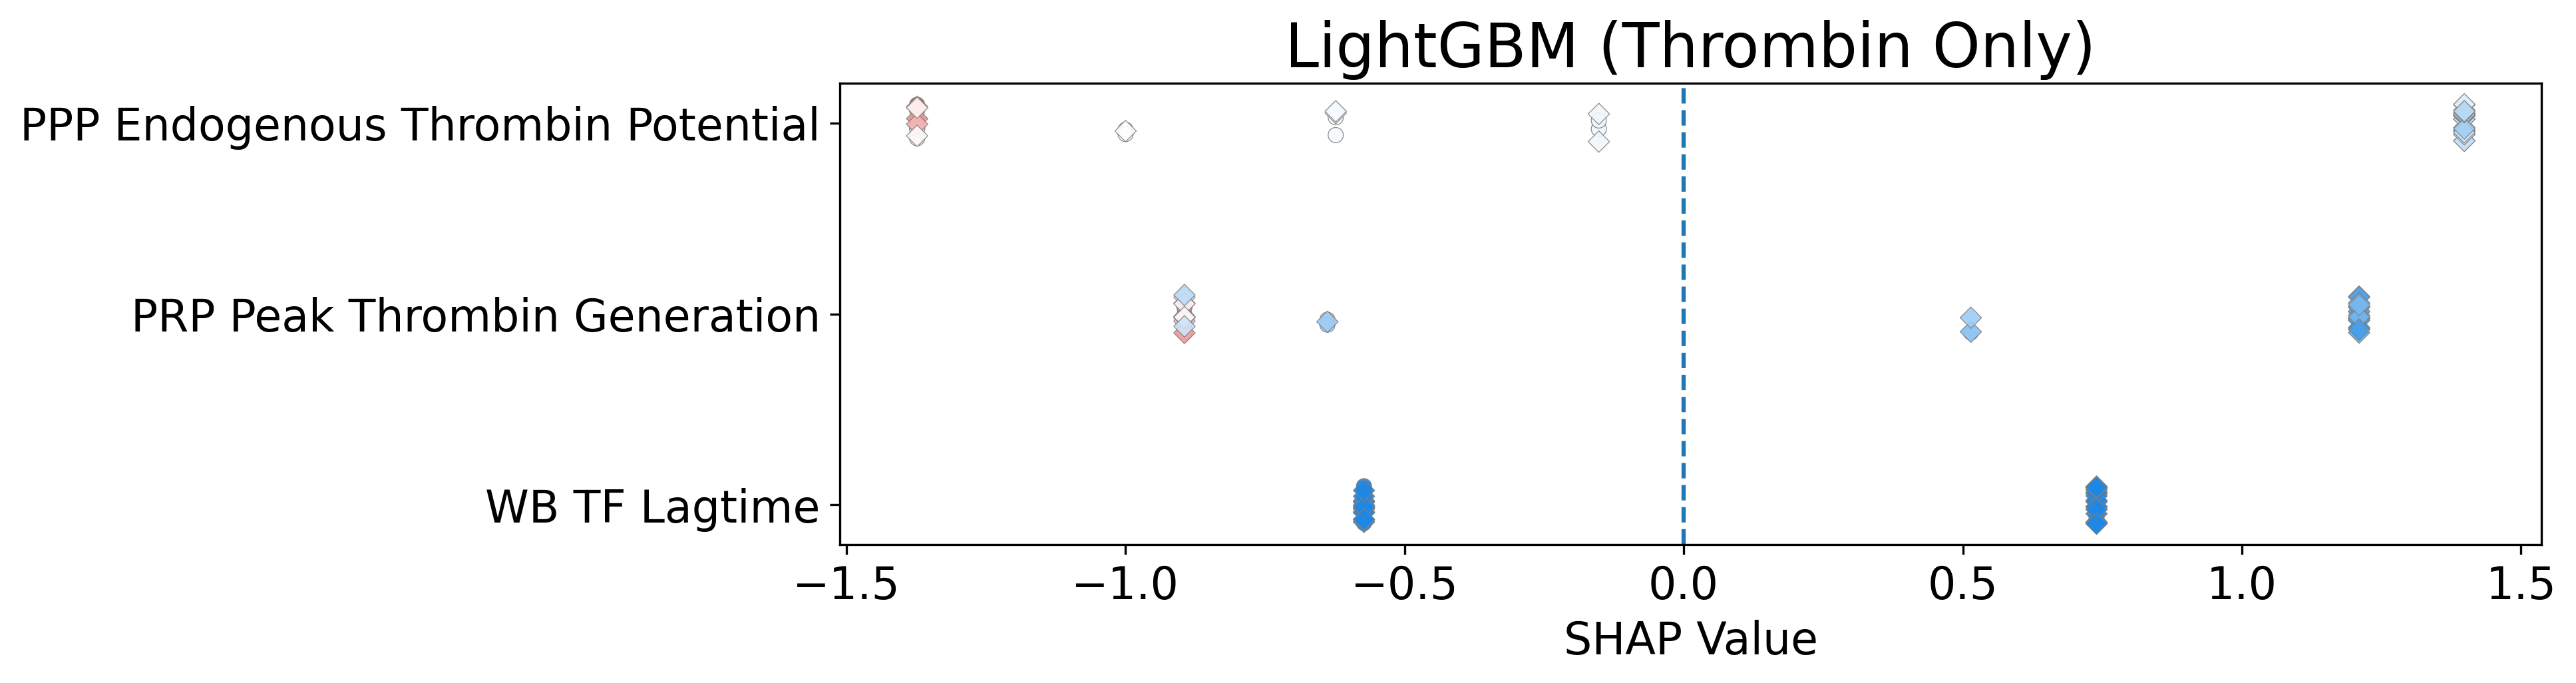


Saved ROC → roc_data/lgbm_thrombin.pkl


In [15]:
warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

# Ensure reproducibility
RANDOM_STATE = 42
N_SPLITS = 5


XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

XGB_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

XGB_data = XGB_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

cols_to_keep = [
    'PRP Endogenous Thrombin Potential',
    'PRP Peak Thrombin Generation',
    'PPP Endogenous Thrombin Potential',
    'PPP Peak Thrombin Generation',
    'WB TF Endogenous Thrombin Potential',
    'WB TM Endogenous Thrombin Potential',
    'WB TF Lagtime'
]

XGB_data.columns = XGB_data.columns.str.strip()
XGB_data = XGB_data.select_dtypes(include=[np.number])  # fix: drop non-numeric

XGB_data = XGB_data[cols_to_keep]
# -----------------------------
# Features + target
# -----------------------------
X = XGB_data.copy()
y = np.array([0]*23 + [1]*32)

# -----------------------------
# Pipeline: impute -> scale -> LGBM
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

param_grid = {
    "clf__max_depth": [2, 3],
    "clf__num_leaves": [4, 8, 16],
    "clf__min_child_samples": [10, 15, 20, 30],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.5, 0.7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__n_estimators": [50, 100, 200],
    "clf__reg_alpha": [0.1, 1.0],   # add L1
    "clf__reg_lambda": [1.0, 5.0],  # add L2
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_lgb = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

model_lgb.fit(X, y)

print("Best LightGBM parameters:", model_lgb.best_params_)
print("Best LightGBM ROC AUC:", model_lgb.best_score_)

# -----------------------------
# CV predictions (no leakage)
# -----------------------------
best_lgb = model_lgb.best_estimator_

y_pred_proba = cross_val_predict(
    best_lgb,
    X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# -----------------------------
# Youden's J
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_pred_proba >= best_threshold).astype(int)

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\nBest threshold (Youden's J):", round(best_threshold, 3))
print("\n==== PERFORMANCE METRICS ====")
print("AUC:", round(auc, 3))
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("PPV:", round(ppv, 3))
print("NPV:", round(npv, 3))
print("F1:", round(f1, 3))

# -----------------------------
# SHAP values
# -----------------------------
X_transformed = best_lgb[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

X = X_shap.copy()
y_array = np.array(y)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

feature_names = X.columns
shap_importance_accum = np.zeros(len(feature_names))

# Store per-fold importance (for stability)
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_array)):
    print(f"Fold {fold+1}/{N_SPLITS}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Train model (same hyperparameters as best_lgb)
    model = LGBMClassifier(**best_lgb["clf"].get_params())
    model.fit(X_train, y_train)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_val)

    # Binary classification → take class 1
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_importance_accum += mean_abs_shap
    fold_importances.append(mean_abs_shap)

# Average importance across folds
shap_importance_mean = shap_importance_accum / N_SPLITS
fold_importances = np.array(fold_importances)

rankings = np.argsort(-fold_importances, axis=1)

# Convert ranks to top-k inclusion (e.g. top 20 per fold)
TOP_K = 20

selection_matrix = np.zeros_like(fold_importances)

for i in range(N_SPLITS):
    selection_matrix[i, rankings[i, :TOP_K]] = 1

# Stability score = proportion of folds selected
stability_score = selection_matrix.mean(axis=0)

# Combine importance + stability
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_shap": shap_importance_mean,
    "stability": stability_score
})

# Selection criteria (tuneable)
selected_features = importance_df[
    (importance_df["stability"] >= 0.6) &  # appears in ≥60% folds
    (importance_df["mean_shap"] > np.percentile(shap_importance_mean, 50))
]["feature"].tolist()

print(f"\nSelected {len(selected_features)} stable features:")
print(selected_features)

X_selected = X[selected_features]

final_model = LGBMClassifier(**best_lgb["clf"].get_params())
final_model.fit(X_selected, y_array)

# SHAP on full data
explainer = shap.TreeExplainer(final_model)
sv_final = explainer.shap_values(X_selected)

if isinstance(sv_final, list):
    sv_final = sv_final[1]

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_final).mean(axis=0)
n_display = min(20, len(selected_features))
feature_order = np.argsort(mean_abs_shap)[::-1][:n_display]
ordered_features = [selected_features[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 3), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_final[:, feat_idx]
    feat_vals = X_selected.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y_array == 0
    case_mask = y_array == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask],
               c=colors[ctrl_mask], marker='o', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')

    ax.scatter(shap_vals[case_mask], y_pos[case_mask],
               c=colors[case_mask], marker='D', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_title(f"LightGBM (Thrombin Only)",
             fontsize=22)



plt.show()


PREFIX = "lgbm_thrombin"

roc_store = {
    "fpr": fpr,
    "tpr": tpr,
    "auc": auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# LightGBM ATP Release 

Best LightGBM parameters: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_samples': 10, 'clf__n_estimators': 200, 'clf__num_leaves': 4, 'clf__reg_alpha': 1.0, 'clf__reg_lambda': 1.0, 'clf__subsample': 0.8}
Best LightGBM ROC AUC: 0.8085714285714287

Best threshold (Youden's J): 0.463

==== PERFORMANCE METRICS ====
AUC: 0.779
Accuracy: 0.727
Sensitivity: 0.781
Specificity: 0.652
PPV: 0.758
NPV: 0.682
F1: 0.769
Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5

Selected 2 stable features:
['Luci GPVI Whole Blood', 'Luci Trap 6 PRP']


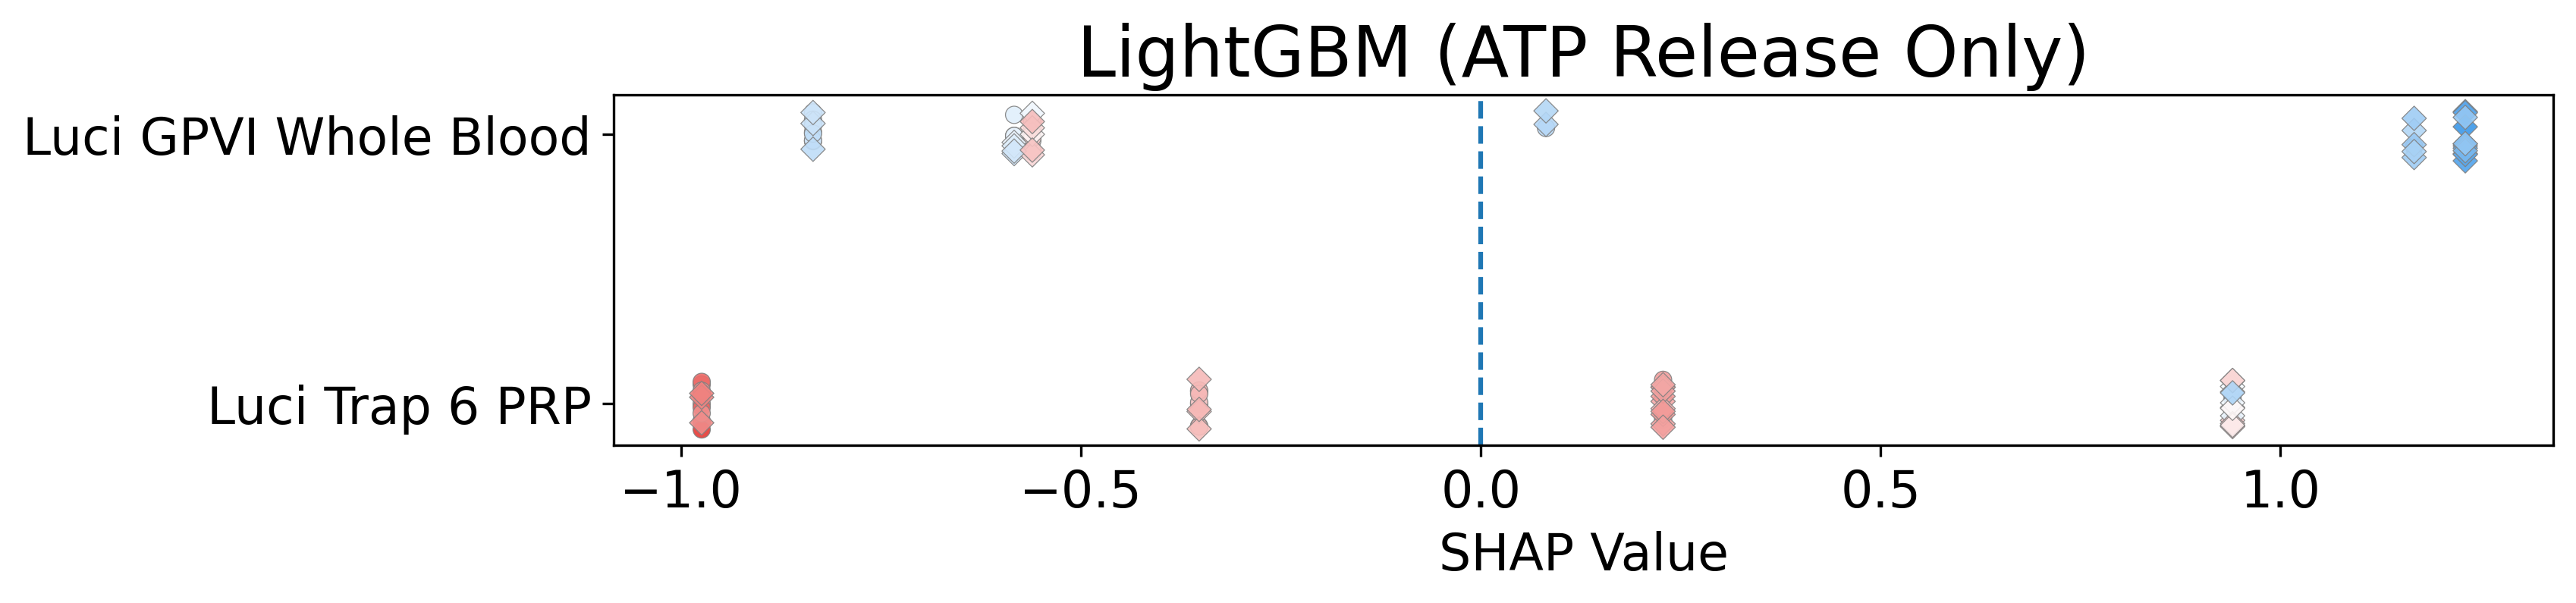


Saved ROC → roc_data/lgbm_atp.pkl


In [16]:
warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

# Ensure reproducibility
RANDOM_STATE = 42
N_SPLITS = 5


XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

XGB_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

XGB_data = XGB_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

cols_to_keep = [
    'Luci Trap 6 Whole Blood',
    'Luci GPVI Whole Blood',
    'Luci Trap 6 PRP',
    'Luci GPVI PRP'
]

XGB_data.columns = XGB_data.columns.str.strip()
XGB_data = XGB_data.select_dtypes(include=[np.number])  # fix: drop non-numeric

XGB_data = XGB_data[cols_to_keep]
# -----------------------------
# Features + target
# -----------------------------
X = XGB_data.copy()
y = np.array([0]*23 + [1]*32)

# -----------------------------
# Pipeline: impute -> scale -> LGBM
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LGBMClassifier(
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

param_grid = {
    "clf__max_depth": [2, 3],
    "clf__num_leaves": [4, 8, 16],
    "clf__min_child_samples": [10, 15, 20, 30],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.5, 0.7],
    "clf__learning_rate": [0.05, 0.1],
    "clf__n_estimators": [50, 100, 200],
    "clf__reg_alpha": [0.1, 1.0],   # add L1
    "clf__reg_lambda": [1.0, 5.0],  # add L2
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_lgb = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

model_lgb.fit(X, y)

print("Best LightGBM parameters:", model_lgb.best_params_)
print("Best LightGBM ROC AUC:", model_lgb.best_score_)

# -----------------------------
# CV predictions (no leakage)
# -----------------------------
best_lgb = model_lgb.best_estimator_

y_pred_proba = cross_val_predict(
    best_lgb,
    X, y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# -----------------------------
# Youden's J
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_pred_proba >= best_threshold).astype(int)

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_pred_proba)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\nBest threshold (Youden's J):", round(best_threshold, 3))
print("\n==== PERFORMANCE METRICS ====")
print("AUC:", round(auc, 3))
print("Accuracy:", round(accuracy, 3))
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))
print("PPV:", round(ppv, 3))
print("NPV:", round(npv, 3))
print("F1:", round(f1, 3))

# -----------------------------
# SHAP values
# -----------------------------
X_transformed = best_lgb[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

X = X_shap.copy()
y_array = np.array(y)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

feature_names = X.columns
shap_importance_accum = np.zeros(len(feature_names))

# Store per-fold importance (for stability)
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_array)):
    print(f"Fold {fold+1}/{N_SPLITS}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_array[train_idx], y_array[val_idx]

    # Train model (same hyperparameters as best_lgb)
    model = LGBMClassifier(**best_lgb["clf"].get_params())
    model.fit(X_train, y_train)

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_val)

    # Binary classification → take class 1
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_importance_accum += mean_abs_shap
    fold_importances.append(mean_abs_shap)

# Average importance across folds
shap_importance_mean = shap_importance_accum / N_SPLITS
fold_importances = np.array(fold_importances)

rankings = np.argsort(-fold_importances, axis=1)

# Convert ranks to top-k inclusion (e.g. top 20 per fold)
TOP_K = 20

selection_matrix = np.zeros_like(fold_importances)

for i in range(N_SPLITS):
    selection_matrix[i, rankings[i, :TOP_K]] = 1

# Stability score = proportion of folds selected
stability_score = selection_matrix.mean(axis=0)

# Combine importance + stability
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_shap": shap_importance_mean,
    "stability": stability_score
})

# Selection criteria (tuneable)
selected_features = importance_df[
    (importance_df["stability"] >= 0.6) &  # appears in ≥60% folds
    (importance_df["mean_shap"] > np.percentile(shap_importance_mean, 50))
]["feature"].tolist()

print(f"\nSelected {len(selected_features)} stable features:")
print(selected_features)

X_selected = X[selected_features]

final_model = LGBMClassifier(**best_lgb["clf"].get_params())
final_model.fit(X_selected, y_array)

# SHAP on full data
explainer = shap.TreeExplainer(final_model)
sv_final = explainer.shap_values(X_selected)

if isinstance(sv_final, list):
    sv_final = sv_final[1]

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_final).mean(axis=0)
n_display = min(20, len(selected_features))
feature_order = np.argsort(mean_abs_shap)[::-1][:n_display]
ordered_features = [selected_features[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 2), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_final[:, feat_idx]
    feat_vals = X_selected.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y_array == 0
    case_mask = y_array == 1

    ax.scatter(shap_vals[ctrl_mask], y_pos[ctrl_mask],
               c=colors[ctrl_mask], marker='o', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')

    ax.scatter(shap_vals[case_mask], y_pos[case_mask],
               c=colors[case_mask], marker='D', s=30, alpha=0.9,
               linewidths=0.3, edgecolors='grey')

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_title(f"LightGBM (ATP Release Only)",
             fontsize=22)



plt.show()


PREFIX = "lgbm_atp"

roc_store = {
    "fpr": fpr,
    "tpr": tpr,
    "auc": auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"\nSaved ROC → roc_data/{PREFIX}.pkl")

# ENR

Best ROC AUC: 0.7728571428571429
Best parameters: {'clf__C': np.float64(0.019306977288832496), 'clf__l1_ratio': 0.1}
Best threshold (Youden's J): 0.576

==== PERFORMANCE METRICS ====
AUC:         0.753
Accuracy:    0.745
Sensitivity: 0.688
Specificity: 0.826
PPV:         0.846
NPV:         0.655
F1:          0.759


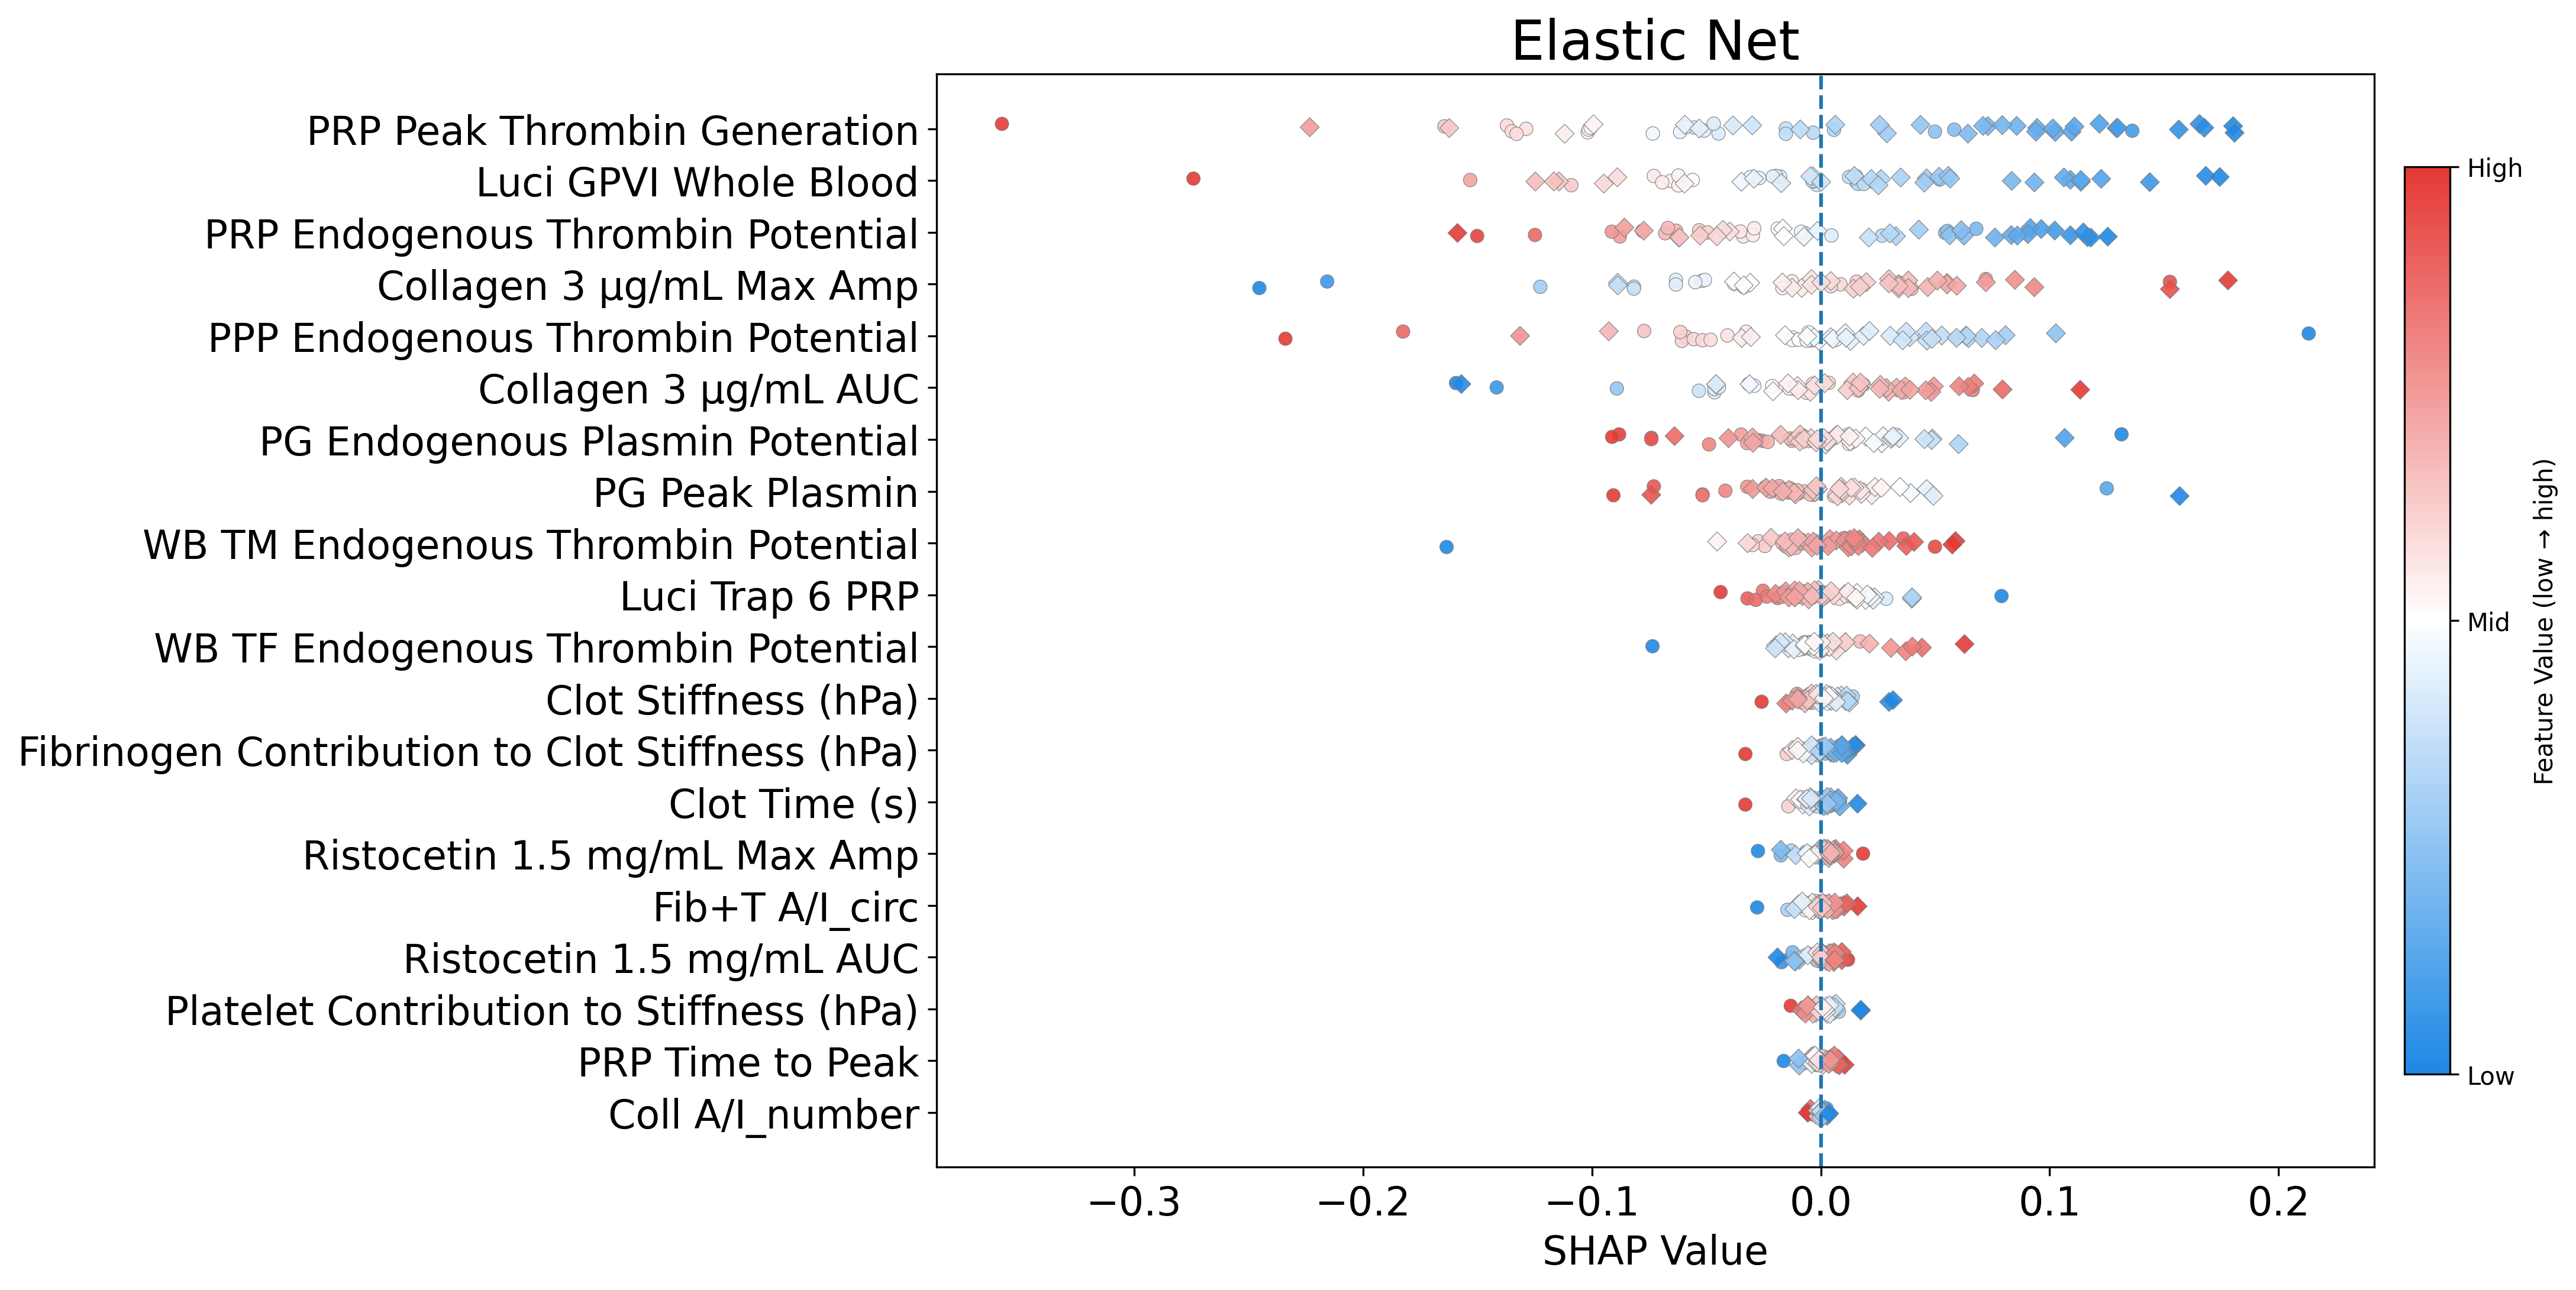

Saved ROC data → roc_data/enr.pkl


In [17]:
from matplotlib.cm import ScalarMappable
from sklearn.linear_model import LogisticRegression
# -----------------------------
# Data loading
# -----------------------------
XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

BDUC_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

BDUC_data.columns = BDUC_data.columns.str.strip()
BDUC_data = BDUC_data.select_dtypes(include=[np.number])



# -----------------------------
# Features + labels
# -----------------------------
X = BDUC_data.copy()

y = np.array([0]*23 + [1]*32)

# -----------------------------
# Elastic net pipeline
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "clf__C": np.logspace(-3, 0, 15),
    "clf__l1_ratio": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0],
}
# 15×7 = 105 combinations — very manageable

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

model.fit(X, y)

print("Best ROC AUC:", model.best_score_)
print("Best parameters:", model.best_params_)

# -----------------------------
# CV predictions
# -----------------------------
best_pipe = model.best_estimator_

y_prob = cross_val_predict(
    best_pipe,
    X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# -----------------------------
# Youden's J threshold
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_prob)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_prob >= best_threshold).astype(int)

print("Best threshold (Youden's J):", round(best_threshold, 3))

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_prob)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE METRICS ====")
print(f"AUC:         {auc:.3f}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV:         {ppv:.3f}")
print(f"NPV:         {npv:.3f}")
print(f"F1:          {f1:.3f}")

# -----------------------------
# SHAP
# -----------------------------
X_transformed = best_pipe[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

explainer_enr = shap.Explainer(
    best_pipe["clf"],
    X_shap
)

shap_values = explainer_enr(X_shap).values

if shap_values.ndim == 3:
    sv_enr = shap_values[:, :, 1]
else:
    sv_enr = shap_values

# -----------------------------
# Manual SHAP beeswarm by group
# -----------------------------
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_enr).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1][:20]  # top 20
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_enr[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y == 0
    ax.scatter(
        shap_vals[ctrl_mask], y_pos[ctrl_mask],
        c=colors[ctrl_mask],
        marker='o', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

    case_mask = y == 1
    ax.scatter(
        shap_vals[case_mask], y_pos[case_mask],
        c=colors[case_mask],
        marker='D', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_title("Elastic Net", fontsize=22)

# -----------------------------
# Colour scale bar
# -----------------------------
sm = ScalarMappable(cmap=shap_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label("Feature Value (low → high)", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Mid", "High"])

# -----------------------------
# Performance metrics below plot
# -----------------------------


plt.show()

# ─────────────────────────────────────────────
# BLOCK 1 – paste at the end of each model script
# Change the prefix (e.g. "enr_top7") to something
# descriptive for that model + feature set combo
# ─────────────────────────────────────────────
import pickle, os

PREFIX = "enr"   # <-- change this for each model

roc_store = {
    "fpr":   fpr,
    "tpr":   tpr,
    "auc":   auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"Saved ROC data → roc_data/{PREFIX}.pkl")

# ENR Thrombin

Best ROC AUC: 0.8285714285714285
Best parameters: {'clf__C': np.float64(0.22758459260747887), 'clf__l1_ratio': 0.0}
Best threshold (Youden's J): 0.64

==== PERFORMANCE METRICS ====
AUC:         0.812
Accuracy:    0.782
Sensitivity: 0.719
Specificity: 0.870
PPV:         0.885
NPV:         0.690
F1:          0.793


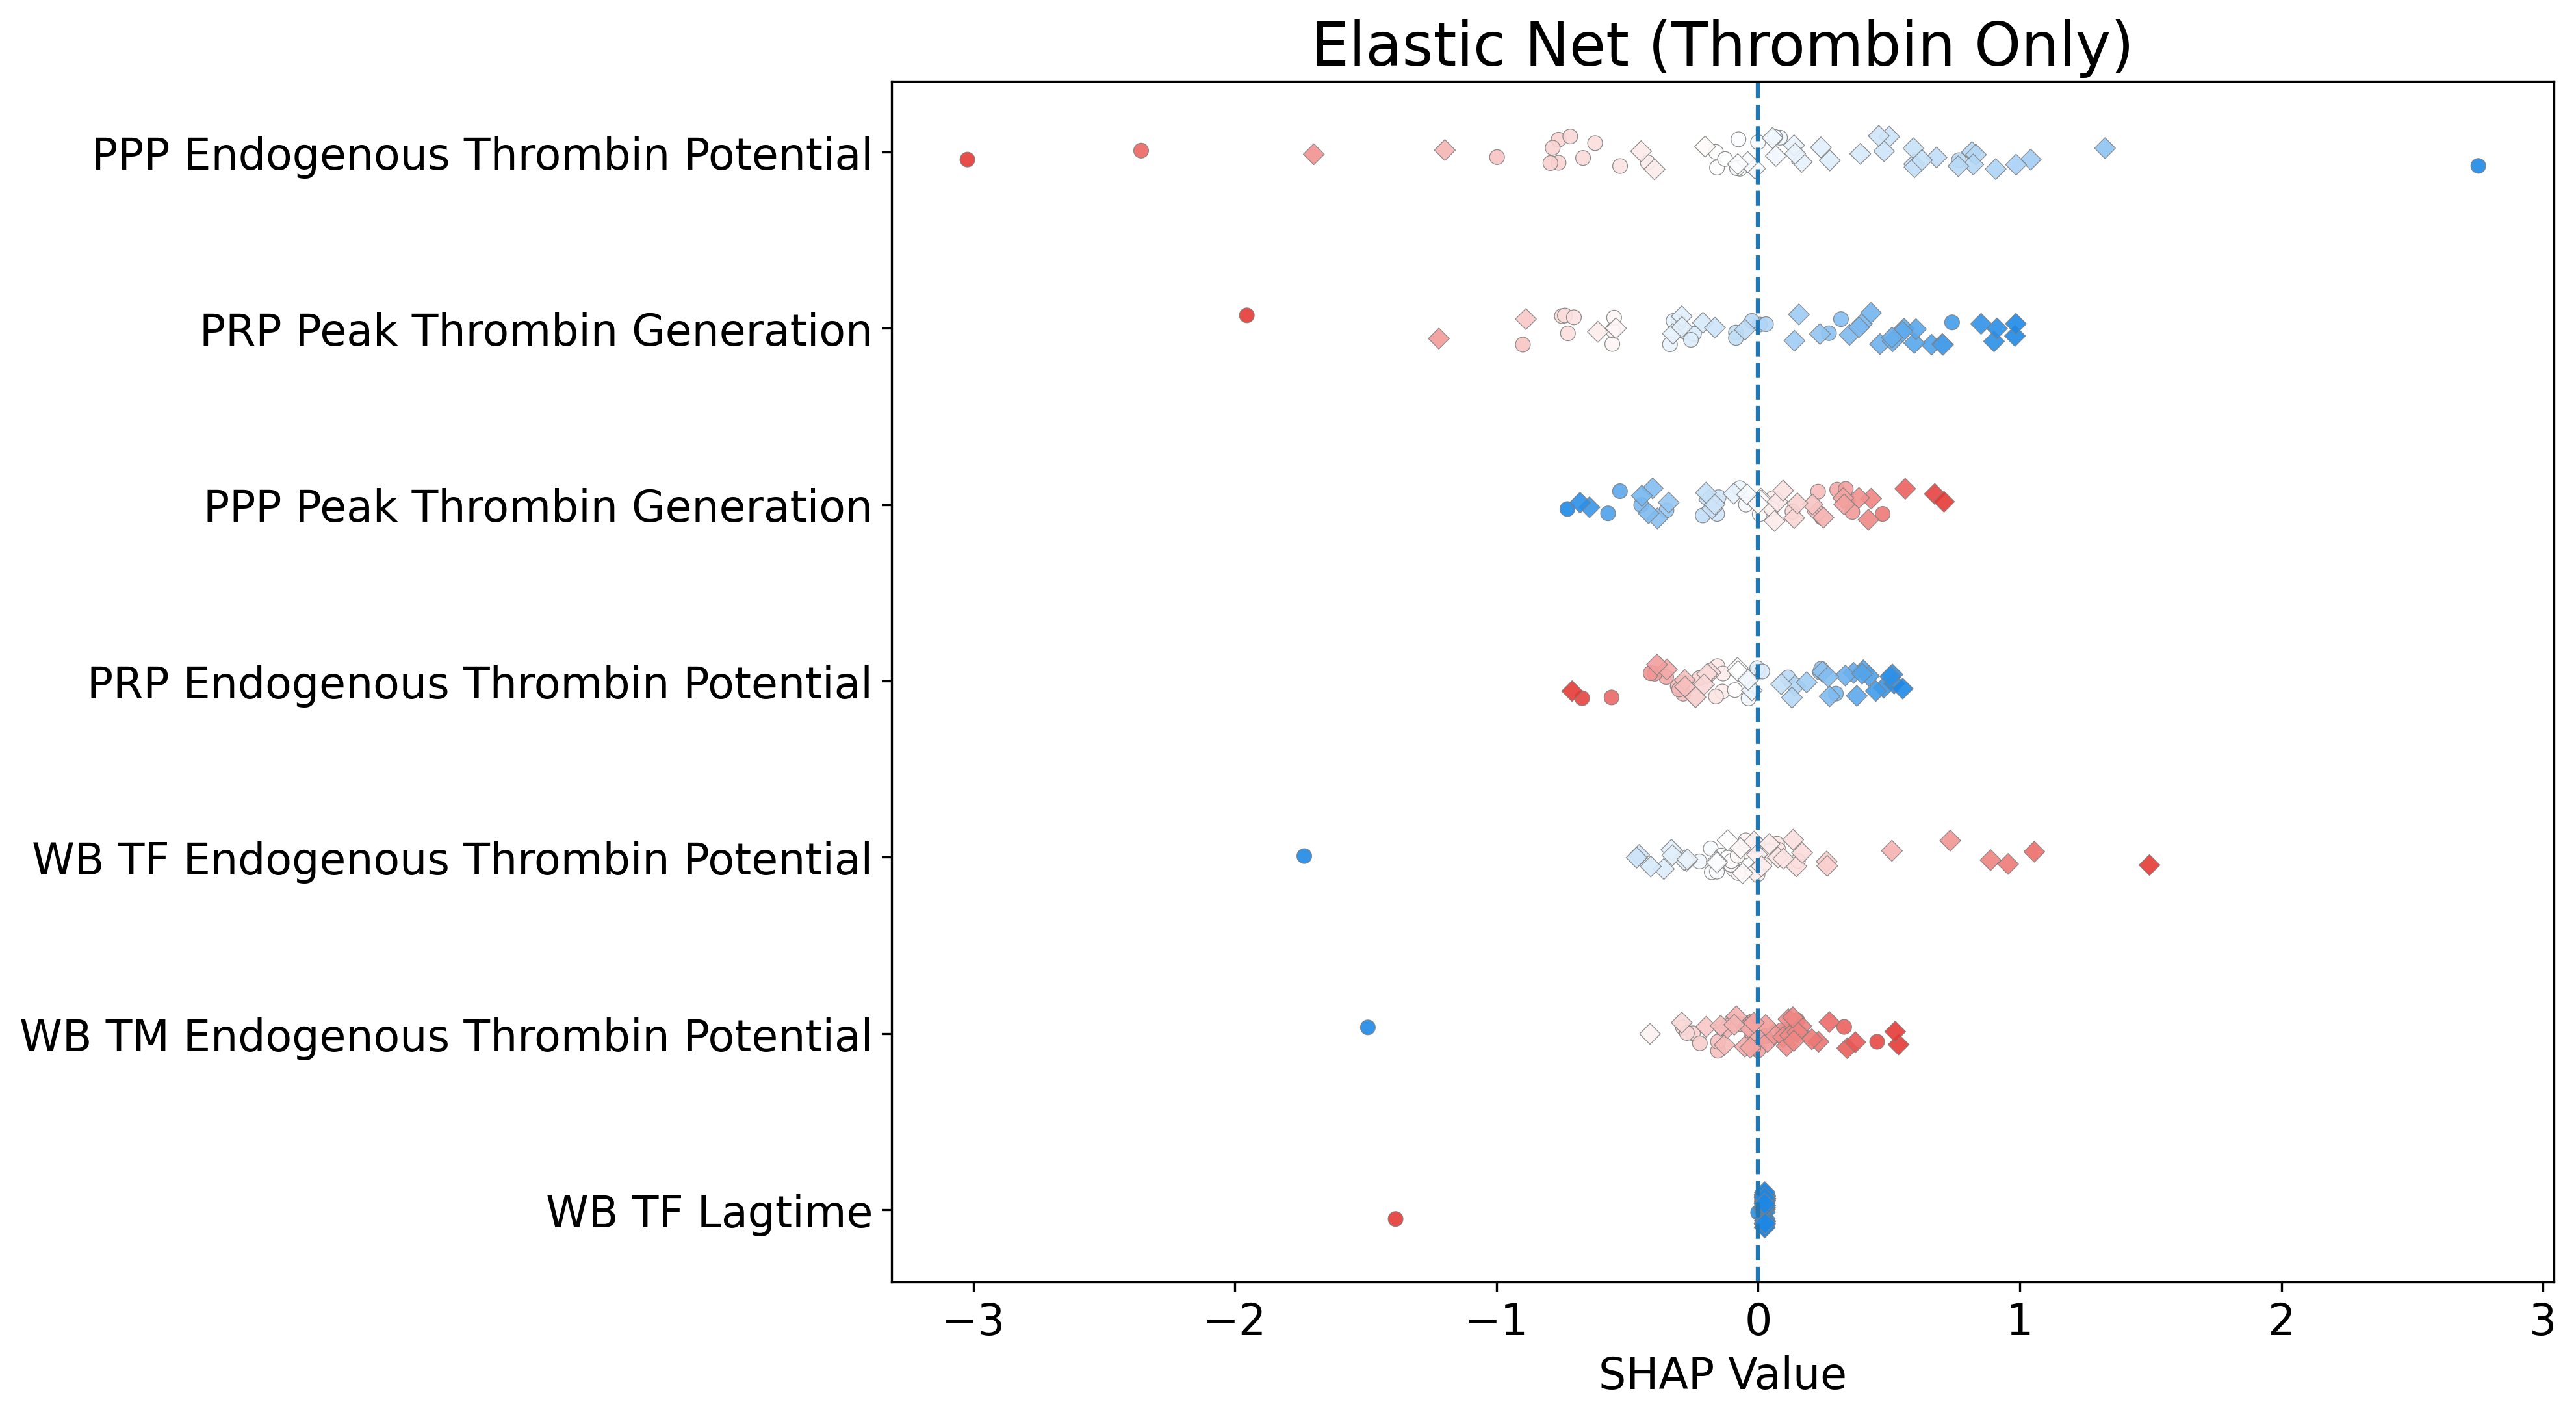

Saved ROC data → roc_data/enr_thrombin.pkl


In [18]:
# -----------------------------
# Data loading
# -----------------------------
XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

BDUC_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

cols_to_keep = [
    'PRP Endogenous Thrombin Potential',
    'PRP Peak Thrombin Generation',
    'PPP Endogenous Thrombin Potential',
    'PPP Peak Thrombin Generation',
    'WB TF Endogenous Thrombin Potential',
    'WB TM Endogenous Thrombin Potential',
    'WB TF Lagtime'
]

BDUC_data = BDUC_data[cols_to_keep]

BDUC_data.columns = BDUC_data.columns.str.strip()
BDUC_data = BDUC_data.select_dtypes(include=[np.number])





# -----------------------------
# Features + labels
# -----------------------------
X = BDUC_data.copy()
y = np.array([0]*23 + [1]*32)

# -----------------------------
# Elastic net pipeline
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "clf__C": np.logspace(-3, 0, 15),
    "clf__l1_ratio": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0],
}
# 15×7 = 105 combinations — very manageable

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

model.fit(X, y)

print("Best ROC AUC:", model.best_score_)
print("Best parameters:", model.best_params_)

# -----------------------------
# CV predictions
# -----------------------------
best_pipe = model.best_estimator_

y_prob = cross_val_predict(
    best_pipe,
    X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# -----------------------------
# Youden's J threshold
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_prob)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_prob >= best_threshold).astype(int)

print("Best threshold (Youden's J):", round(best_threshold, 3))

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_prob)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE METRICS ====")
print(f"AUC:         {auc:.3f}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV:         {ppv:.3f}")
print(f"NPV:         {npv:.3f}")
print(f"F1:          {f1:.3f}")

# -----------------------------
# SHAP
# -----------------------------
X_transformed = best_pipe[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

explainer_enr = shap.Explainer(
    best_pipe["clf"],
    X_shap
)

shap_values = explainer_enr(X_shap).values

if shap_values.ndim == 3:
    sv_enr = shap_values[:, :, 1]
else:
    sv_enr = shap_values

# -----------------------------
# Manual SHAP beeswarm by group
# -----------------------------
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_enr).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1][:20]  # top 20
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_enr[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y == 0
    ax.scatter(
        shap_vals[ctrl_mask], y_pos[ctrl_mask],
        c=colors[ctrl_mask],
        marker='o', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

    case_mask = y == 1
    ax.scatter(
        shap_vals[case_mask], y_pos[case_mask],
        c=colors[case_mask],
        marker='D', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.set_title("Elastic Net (Thrombin Only)", fontsize=22)
ax.tick_params(axis='x', labelsize=16)



plt.show()

# ─────────────────────────────────────────────
# BLOCK 1 – paste at the end of each model script
# Change the prefix (e.g. "enr_top7") to something
# descriptive for that model + feature set combo
# ─────────────────────────────────────────────
import pickle, os

PREFIX = "enr_thrombin"   # <-- change this for each model

roc_store = {
    "fpr":   fpr,
    "tpr":   tpr,
    "auc":   auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"Saved ROC data → roc_data/{PREFIX}.pkl")


# ENR ATP Release

Best ROC AUC: 0.7623809523809524
Best parameters: {'clf__C': np.float64(0.3727593720314938), 'clf__l1_ratio': 0.3}
Best threshold (Youden's J): 0.646

==== PERFORMANCE METRICS ====
AUC:         0.748
Accuracy:    0.727
Sensitivity: 0.625
Specificity: 0.870
PPV:         0.870
NPV:         0.625
F1:          0.727


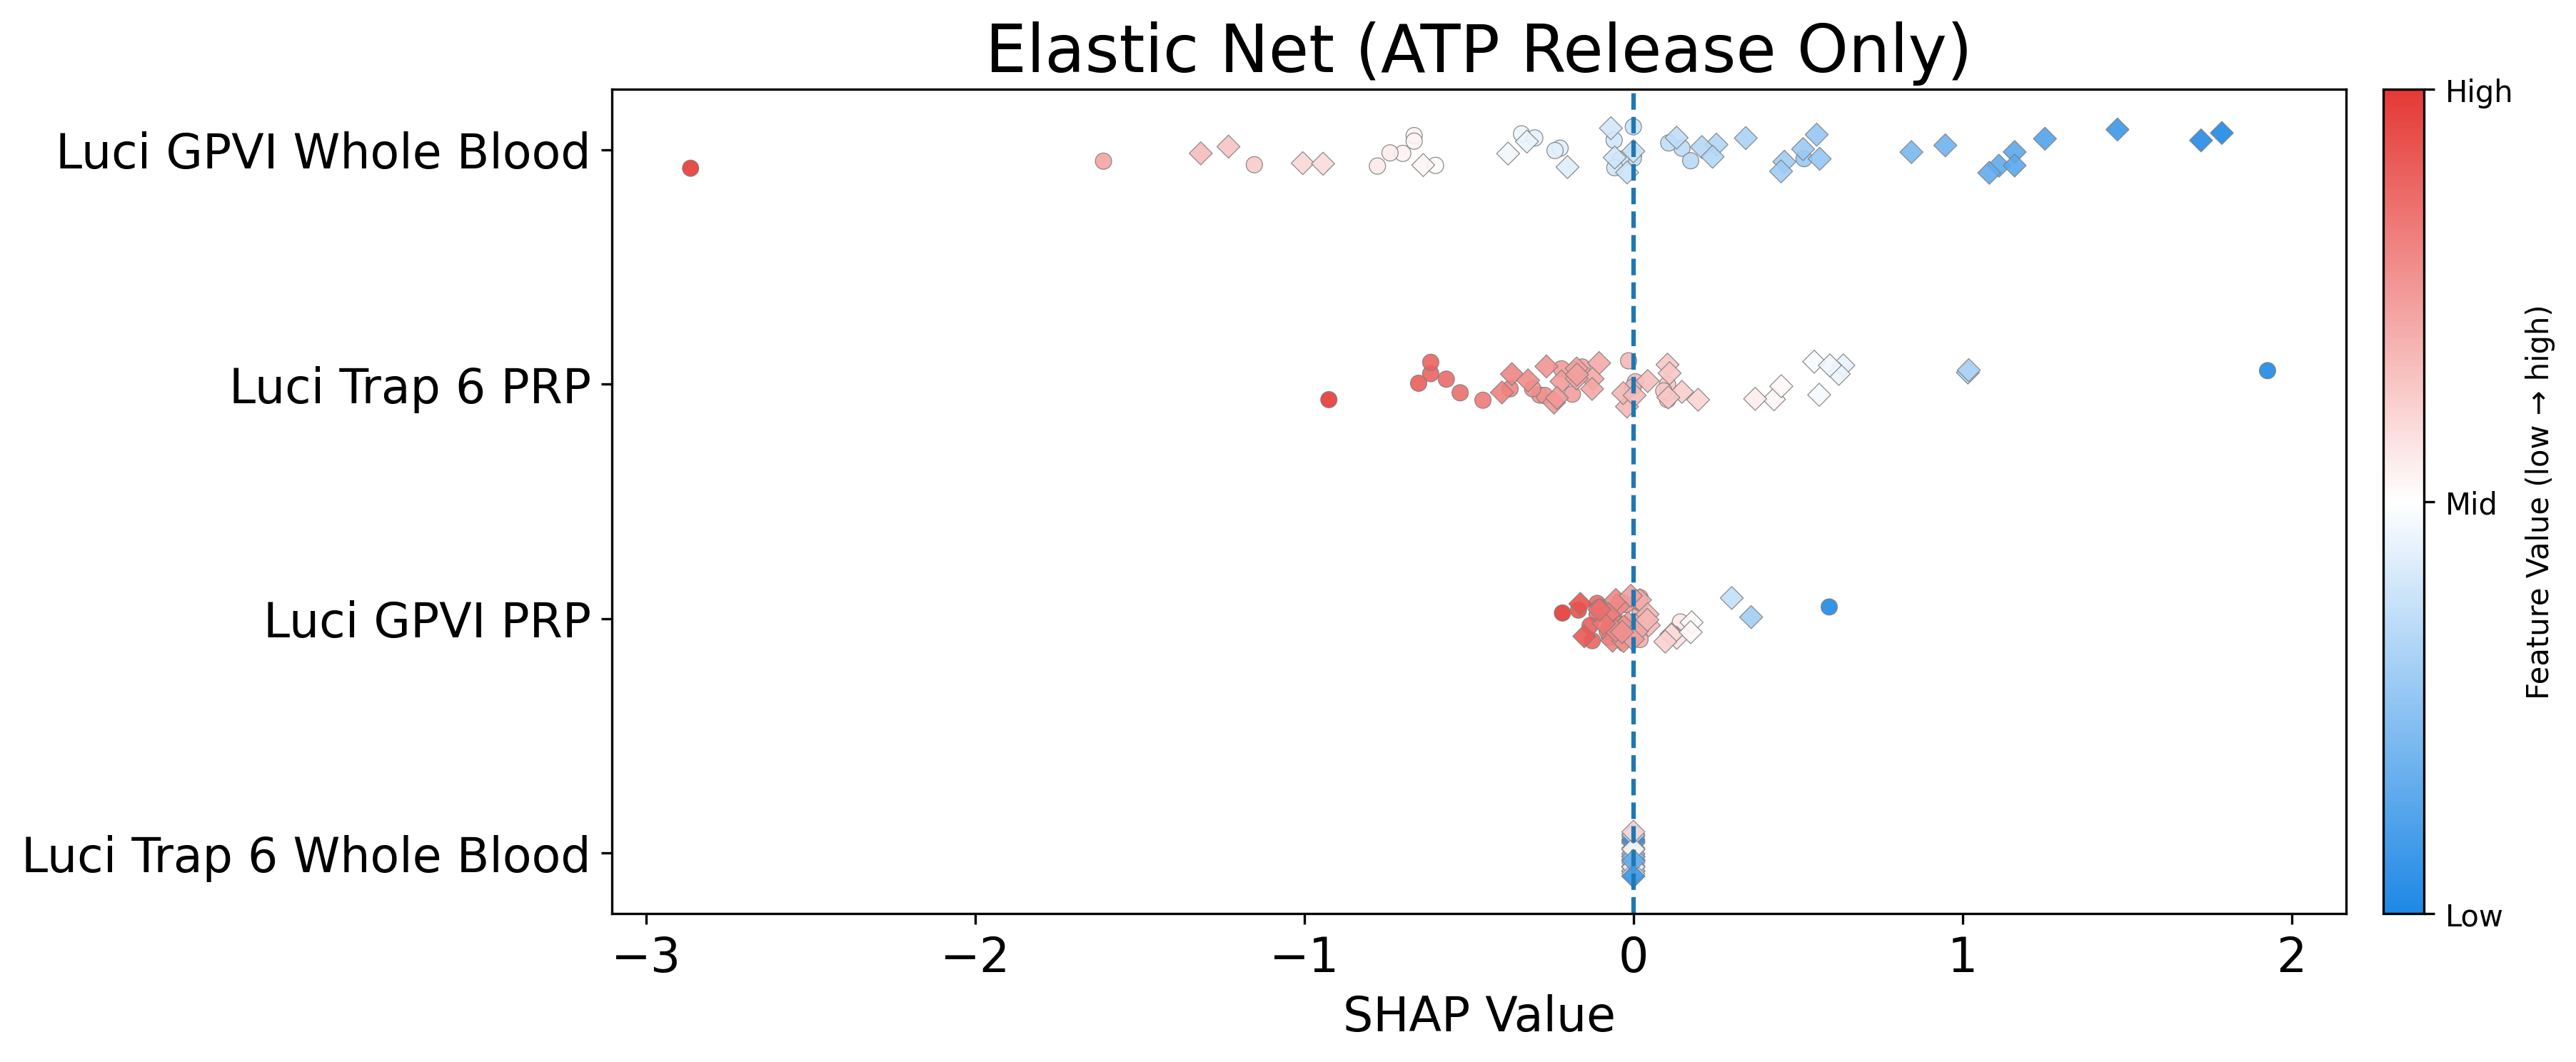

Saved ROC data → roc_data/enr_atp.pkl


In [19]:
# -----------------------------
# Data loading
# -----------------------------
XGB_patients = pd.read_excel('BDUC_ML.xlsx')
XGB_control = pd.read_excel('BDUC_Controls.xlsx')

BDUC_data = pd.concat(
    [XGB_control, XGB_patients],
    axis=0,
    ignore_index=True
)

BDUC_data = BDUC_data.drop(
    columns=['BDUC #', 'c', 'Age', 'Sex', 'BAT Score', 'Platelet Count (x10^9/L)'],
    errors="ignore"
)

cols_to_keep = [
    'Luci Trap 6 Whole Blood',
    'Luci GPVI Whole Blood',
    'Luci Trap 6 PRP',
    'Luci GPVI PRP'
]

BDUC_data = BDUC_data[cols_to_keep]

BDUC_data.columns = BDUC_data.columns.str.strip()
BDUC_data = BDUC_data.select_dtypes(include=[np.number])





# -----------------------------
# Features + labels
# -----------------------------
X = BDUC_data.copy()
y = np.array([0]*23 + [1]*32)

# -----------------------------
# Elastic net pipeline
# -----------------------------
pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=3)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "clf__C": np.logspace(-3, 0, 15),
    "clf__l1_ratio": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0],
}
# 15×7 = 105 combinations — very manageable

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

model.fit(X, y)

print("Best ROC AUC:", model.best_score_)
print("Best parameters:", model.best_params_)

# -----------------------------
# CV predictions
# -----------------------------
best_pipe = model.best_estimator_

y_prob = cross_val_predict(
    best_pipe,
    X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

# -----------------------------
# Youden's J threshold
# -----------------------------
fpr, tpr, thresholds = roc_curve(y, y_prob)
youden_j = tpr - fpr
best_threshold = thresholds[np.argmax(youden_j)]
y_pred = (y_prob >= best_threshold).astype(int)

print("Best threshold (Youden's J):", round(best_threshold, 3))

# -----------------------------
# Metrics
# -----------------------------
auc         = roc_auc_score(y, y_prob)
accuracy    = accuracy_score(y, y_pred)
sensitivity = recall_score(y, y_pred, pos_label=1)
specificity = recall_score(y, y_pred, pos_label=0)
ppv         = precision_score(y, y_pred, pos_label=1)
npv         = precision_score(y, y_pred, pos_label=0)
f1          = f1_score(y, y_pred)

print("\n==== PERFORMANCE METRICS ====")
print(f"AUC:         {auc:.3f}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV:         {ppv:.3f}")
print(f"NPV:         {npv:.3f}")
print(f"F1:          {f1:.3f}")

# -----------------------------
# SHAP
# -----------------------------
X_transformed = best_pipe[:-1].transform(X)
cols_to_keep = X.columns.tolist()
X_shap = pd.DataFrame(X_transformed, columns=cols_to_keep)

explainer_enr = shap.Explainer(
    best_pipe["clf"],
    X_shap
)

shap_values = explainer_enr(X_shap).values

if shap_values.ndim == 3:
    sv_enr = shap_values[:, :, 1]
else:
    sv_enr = shap_values

# -----------------------------
# Manual SHAP beeswarm by group
# -----------------------------
shap_cmap = LinearSegmentedColormap.from_list(
    "shap_cmap", ["#1E88E5", "#FFFFFF", "#E53935"]
)

mean_abs_shap = np.abs(sv_enr).mean(axis=0)
feature_order = np.argsort(mean_abs_shap)[::-1][:20]  # top 20
ordered_features = [cols_to_keep[i] for i in feature_order]

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

for plot_idx, feat_idx in enumerate(reversed(feature_order)):
    shap_vals = sv_enr[:, feat_idx]
    feat_vals = X_shap.iloc[:, feat_idx].values

    vmin, vmax = feat_vals.min(), feat_vals.max()
    norm_vals = (feat_vals - vmin) / (vmax - vmin + 1e-8)
    colors = shap_cmap(norm_vals)

    jitter = np.random.uniform(-0.1, 0.1, size=len(shap_vals))
    y_pos = plot_idx + jitter

    ctrl_mask = y == 0
    ax.scatter(
        shap_vals[ctrl_mask], y_pos[ctrl_mask],
        c=colors[ctrl_mask],
        marker='o', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

    case_mask = y == 1
    ax.scatter(
        shap_vals[case_mask], y_pos[case_mask],
        c=colors[case_mask],
        marker='D', s=30, alpha=0.9, linewidths=0.3, edgecolors='grey'
    )

ax.set_yticks(range(len(feature_order)))
ax.set_yticklabels(list(reversed(ordered_features)), fontsize=16)
ax.axvline(0, linestyle='--')
ax.set_xlabel("SHAP Value", fontsize=16)
ax.set_title("Elastic Net (ATP Release Only)", fontsize=22)
ax.tick_params(axis='x', labelsize=16)

# -----------------------------
# Colour scale bar
# -----------------------------
sm = ScalarMappable(cmap=shap_cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label("Feature Value (low → high)", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Mid", "High"])


plt.show()

# ─────────────────────────────────────────────
# BLOCK 1 – paste at the end of each model script
# Change the prefix (e.g. "enr_top7") to something
# descriptive for that model + feature set combo
# ─────────────────────────────────────────────
import pickle, os

PREFIX = "enr_atp"   # <-- change this for each model

roc_store = {
    "fpr":   fpr,
    "tpr":   tpr,
    "auc":   auc,
    "label": PREFIX,
}

os.makedirs("roc_data", exist_ok=True)
with open(f"roc_data/{PREFIX}.pkl", "wb") as f:
    pickle.dump(roc_store, f)

print(f"Saved ROC data → roc_data/{PREFIX}.pkl")

# ROC Curve

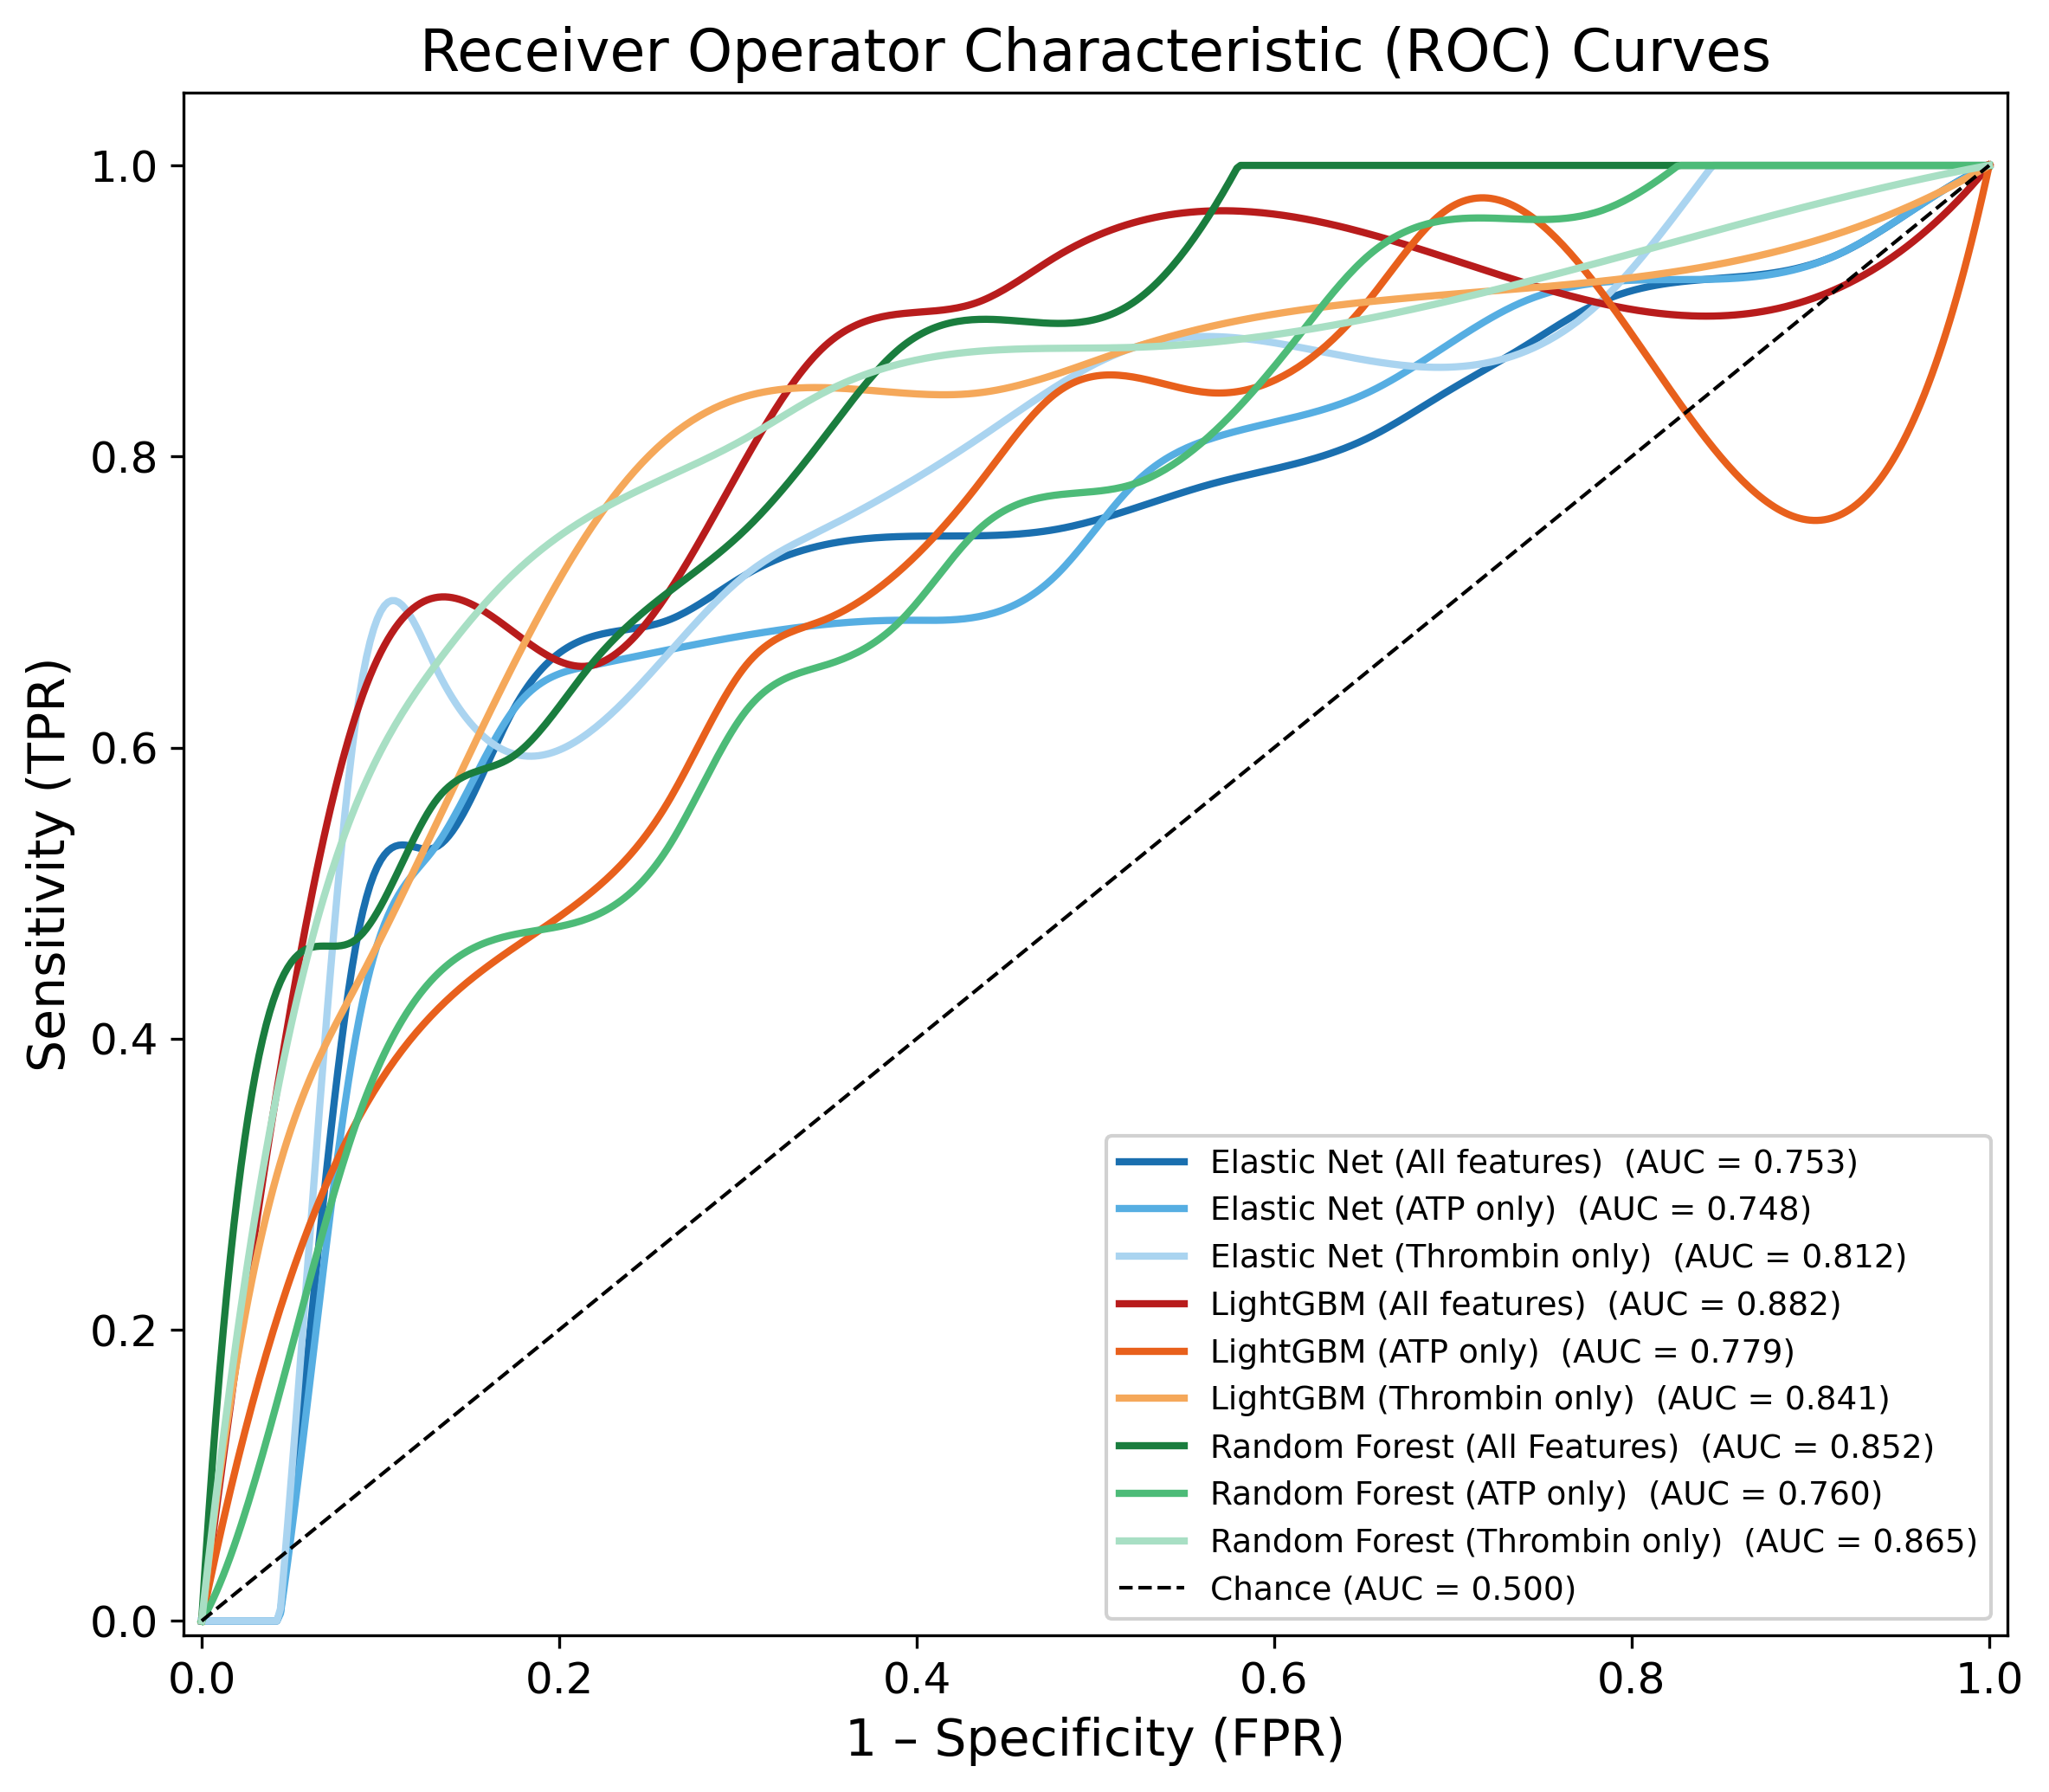

Saved → roc_all_models.png


In [21]:
from scipy.interpolate import make_interp_spline

# -----------------------------
# CONFIG
# -----------------------------
ROC_DIR = "roc_data"

MODEL_CONFIG = {
    "enr":           "Elastic Net (All features)",
    "enr_thrombin":  "Elastic Net (Thrombin only)",
    "enr_atp":       "Elastic Net (ATP only)",
    "rf_boruta":     "Random Forest (All Features)",
    "rf_thrombin":   "Random Forest (Thrombin only)",
    "rf_atp":        "Random Forest (ATP only)",
    "lgbm":          "LightGBM (All features)",
    "lgbm_thrombin": "LightGBM (Thrombin only)",
    "lgbm_atp":      "LightGBM (ATP only)"
}

COLOURS = [
    "#1a6faf",
    "#56aee2",
    "#aad4f0",
    "#b81c1c",
    "#e8601c",
    "#f5a85a",
    "#1a7d3e",
    "#4dbb78",
    "#a8dfc4",
]

# -----------------------------
# SMOOTH HELPER
# -----------------------------
def smooth_roc(fpr, tpr, n_points=500):
    fpr = np.array(fpr)
    tpr = np.array(tpr)
    fpr, idx = np.unique(fpr, return_index=True)
    tpr = tpr[idx]
    if len(fpr) < 4:
        return fpr, tpr
    fpr_new = np.linspace(fpr[0], fpr[-1], n_points)
    tpr_new = np.clip(make_interp_spline(fpr, tpr, k=3)(fpr_new), 0.0, 1.0)
    return fpr_new, tpr_new

# -----------------------------
# LOAD
# -----------------------------
roc_entries = []

for fname in sorted(f for f in os.listdir(ROC_DIR) if f.endswith(".pkl")):
    prefix = fname.replace(".pkl", "")
    with open(os.path.join(ROC_DIR, fname), "rb") as f:
        data = pickle.load(f)
    roc_entries.append({
        "fpr":   data["fpr"],
        "tpr":   data["tpr"],
        "auc":   data["auc"],
        "label": MODEL_CONFIG.get(prefix, prefix),
    })

roc_entries.sort(key=lambda x: x["label"].lower())

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

for i, entry in enumerate(roc_entries):
    fpr_s, tpr_s = smooth_roc(entry["fpr"], entry["tpr"])
    ax.plot(
        fpr_s, tpr_s,
        color=COLOURS[i % len(COLOURS)],
        lw=2,
        label=f'{entry["label"]}  (AUC = {entry["auc"]:.3f})'
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance (AUC = 0.500)")

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
ax.set_xlabel("1 – Specificity (FPR)", fontsize=14)
ax.set_ylabel("Sensitivity (TPR)", fontsize=14)
ax.set_title("Receiver Operator Characteristic (ROC) Curves", fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("roc_all_models.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → roc_all_models.png")